# Notebook - Find best Drug compound for different viruses
- Marburg virus
- Ebola virus
- Lassa virus
- Nipah virus
- Venezuelan equine encephalitis virus (VEEV)
- Hantavirus
- SARS-CoV
- SARS-CoV-2

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [187]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [188]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from copy import deepcopy

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [189]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [190]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [191]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

### Filter columns

In [192]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allVirusData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL5087131,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,4.0000,NaN,SARS-CoV-2
1,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0100,8.000000,SARS-CoV-2
2,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,15.0000,4.823909,SARS-CoV-2
3,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,10.0500,4.997834,SARS-CoV-2
4,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,0.0640,7.193820,SARS-CoV-2
...,...,...,...,...,...
14492,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,4.6000,5.337242,Marburg
14493,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,25.0000,4.602060,Marburg
14494,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,0.0013,8.886057,Hanta
14495,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,0.0016,8.795880,Hanta


### Add some randomization

### Rename columns

In [193]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Virus" : "VirusClassifier",
})

### Compound Distribution Across Viruses

In [194]:
virus_counts = allVirusData_chEMBL_wMACAW['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(allVirusData_chEMBL_wMACAW)

print(f"\n{'Virus':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Virus                               Count   Percentage
----------------------------------------------------------------------
SARS-CoV-2                          12854       88.67%
Ebola                                 726        5.01%
SARS-CoV                              275        1.90%
Lassa                                 217        1.50%
VEEV                                  209        1.44%
Marburg                               203        1.40%
Nipah                                  10        0.07%
Hanta                                   3        0.02%
----------------------------------------------------------------------
TOTAL                               14497      100.00%

Number of unique viruses: 8


### Add `ID` column to left

In [195]:
allVirusData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(allVirusData_chEMBL_wMACAW) + 1))
allVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,VirusClassifier
0,1,CHEMBL5087131,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,4.000,NaN,SARS-CoV-2
1,2,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.010,8.000000,SARS-CoV-2
2,3,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,15.000,4.823909,SARS-CoV-2
3,4,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,10.050,4.997834,SARS-CoV-2
4,5,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,0.064,7.193820,SARS-CoV-2


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [196]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
allVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
0,1,CHEMBL5087131,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,NaN,SARS-CoV-2
1,2,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,8.000000,SARS-CoV-2
2,3,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,4.823909,SARS-CoV-2
3,4,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,4.997834,SARS-CoV-2
4,5,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,7.193820,SARS-CoV-2


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [197]:
print("Original shape:", allVirusData_chEMBL_wMACAW.shape)

allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['pPotency'].notna() 
    & (allVirusData_chEMBL_wMACAW['pPotency'] > 0) ]   # & (allVirusData_chEMBL_wMACAW['pPotency'] < 12)

print("Shape after cleaning 'pPotency' value:", allVirusData_chEMBL_wMACAW.shape)

Original shape: (14497, 5)
Shape after cleaning 'pPotency' value: (4694, 5)


In [198]:
allVirusData_chEMBL_wMACAW

,ID,compound_id,Smiles,pPotency,VirusClassifier
1,2,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,8.000000,SARS-CoV-2
2,3,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,4.823909,SARS-CoV-2
3,4,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,4.997834,SARS-CoV-2
4,5,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,7.193820,SARS-CoV-2
5,6,CHEMBL46286,COC(=O)C[C@](O)(CCCC(C)(C)O)C(=O)O[C@@H]1C(OC)...,5.677781,SARS-CoV-2
...,...,...,...,...,...
14492,14493,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,5.337242,Marburg
14493,14494,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,4.602060,Marburg
14494,14495,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,8.886057,Hanta
14495,14496,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,8.795880,Hanta


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [199]:
duplicates = allVirusData_chEMBL_wMACAW.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 1990


In [ ]:
# Get counts and percentages
counts = allVirusData_chEMBL_wMACAW['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [201]:
allVirusData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_wMACAW_MLready.csv"), index=False)

### Arrange Virus alphabetically

In [202]:
allVirusData_chEMBL_wMACAW_ordered = allVirusData_chEMBL_wMACAW.sort_values(by='VirusClassifier')
allVirusData_chEMBL_wMACAW_ordered.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
13202,13203,CHEMBL4454384,c1cc(NCCCN2CCOCC2)c2nccc(NCCCN3CCOCC3)c2n1,5.000000,Ebola
13552,13553,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,7.221849,Ebola
13553,13554,CHEMBL5084473,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,6.346787,Ebola
13554,13555,CHEMBL5290974,COC(=O)[C@H]1C[C@H](OCCN)[C@@H](O[C@H]2O[C@H](...,3.207608,Ebola
13555,13556,CHEMBL5287023,CCN(CC)Cc1cc(Nc2c(Oc3ccccc3)cnc3cc(Cl)ccc23)ccc1O,6.136677,Ebola


### pPotency value distribution across each Virus

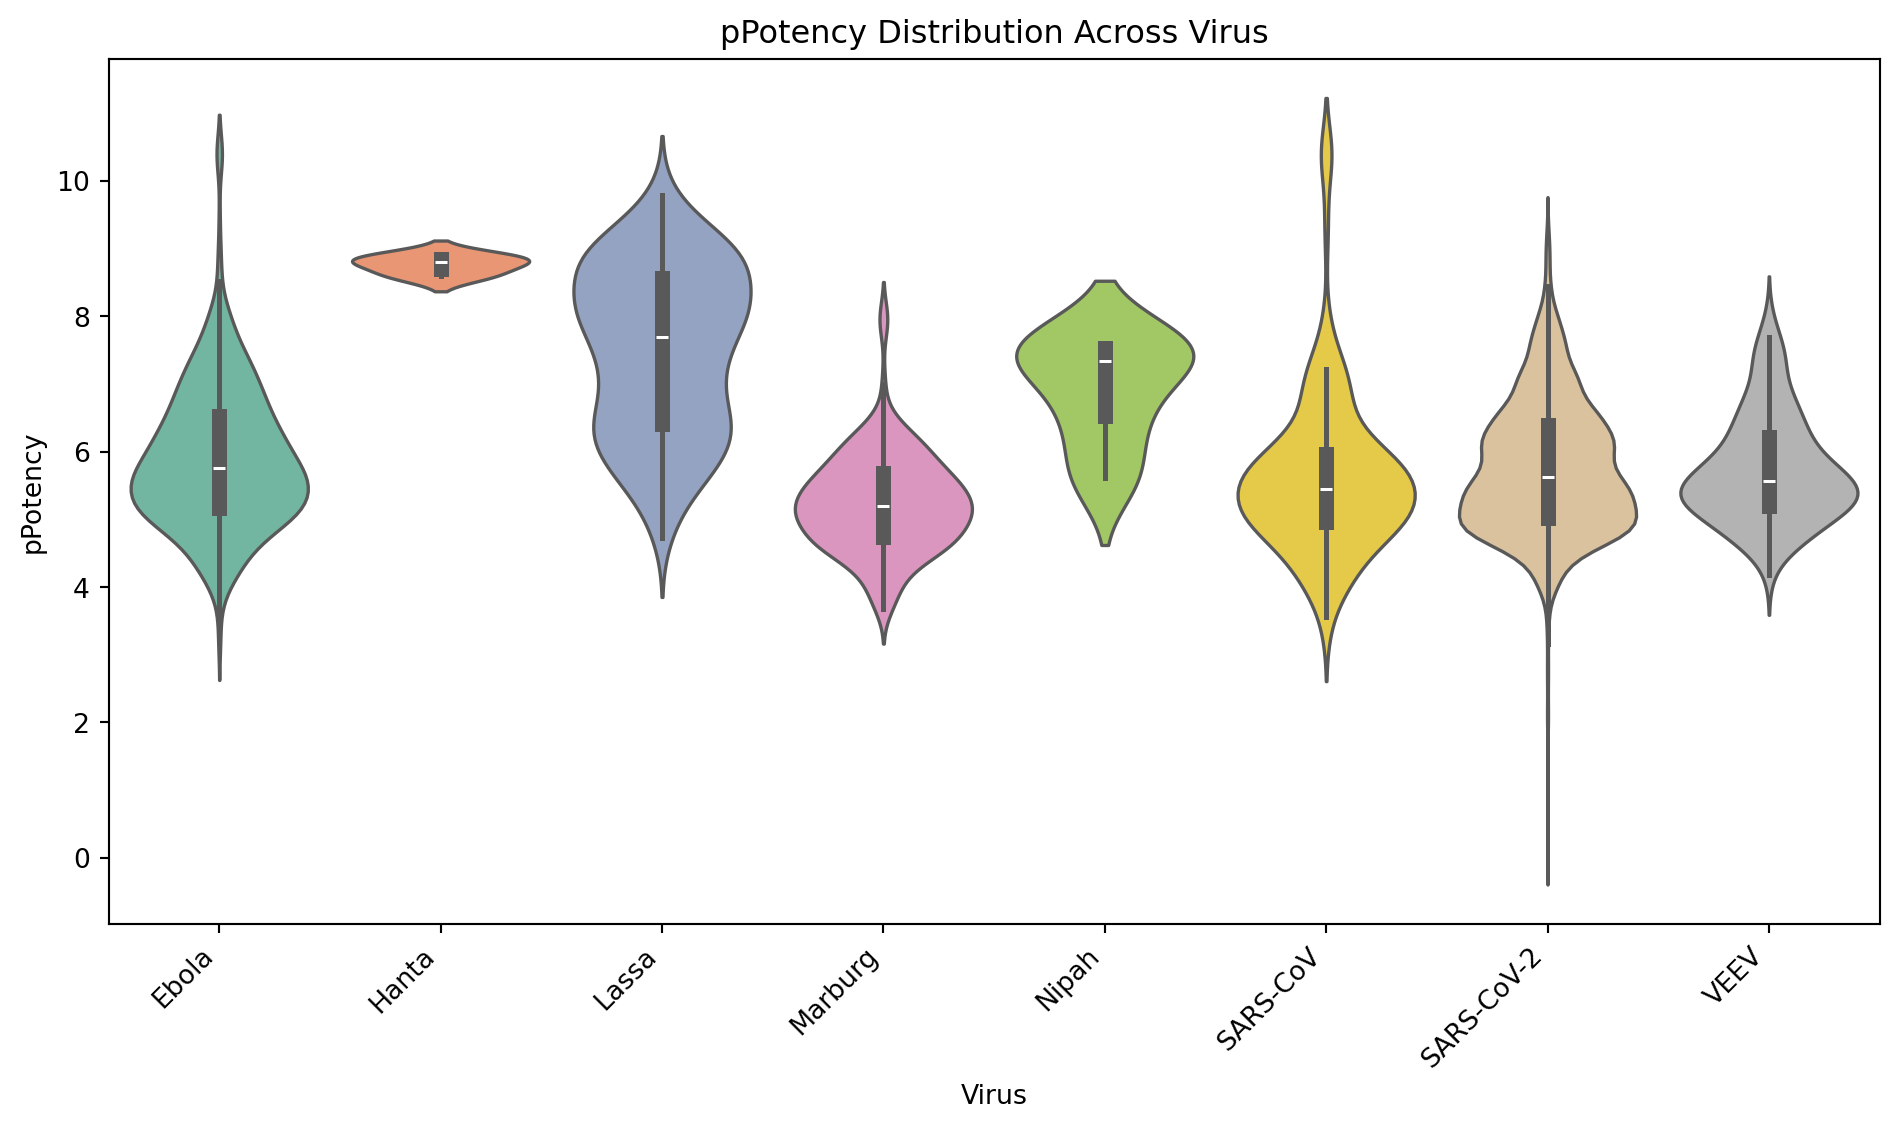

In [203]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=allVirusData_chEMBL_wMACAW_ordered,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

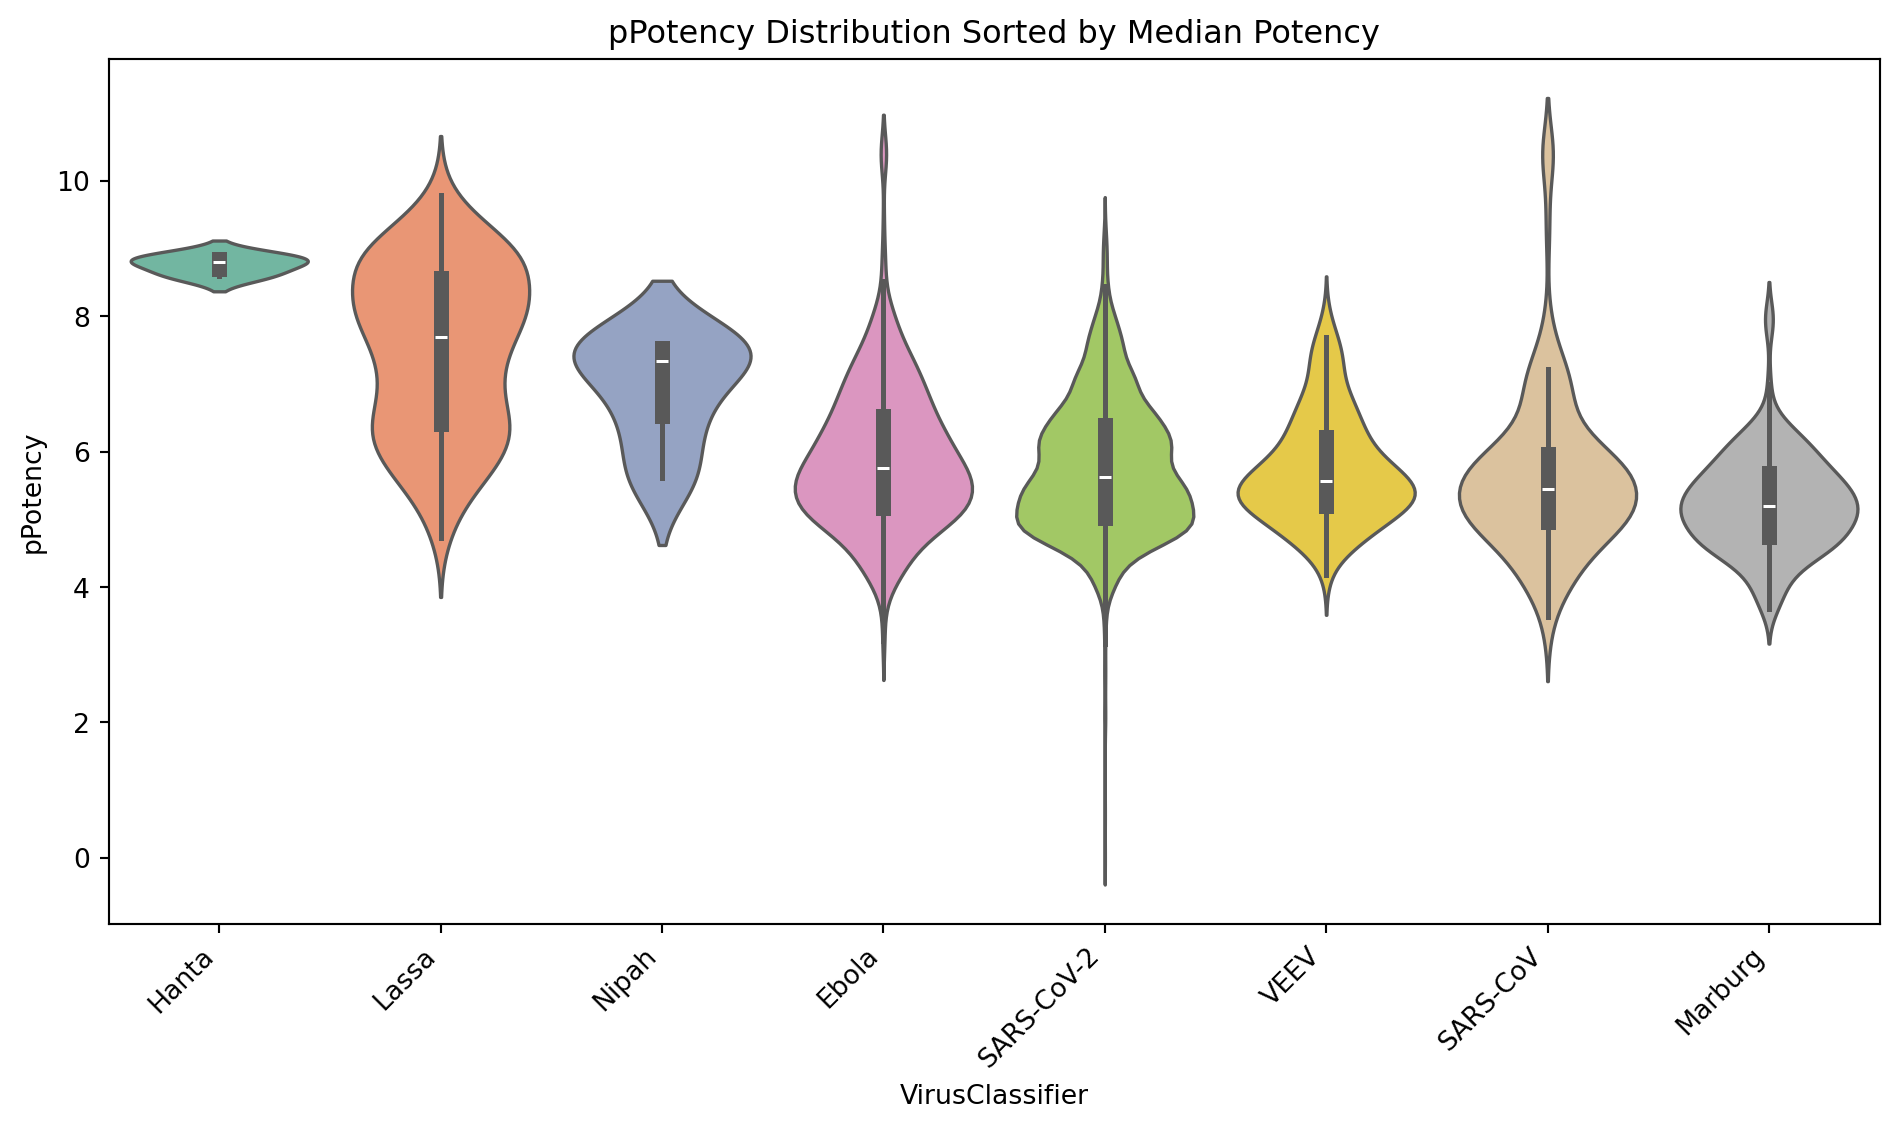

In [204]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=allVirusData_chEMBL_wMACAW_ordered,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    order=(
        allVirusData_chEMBL_wMACAW_ordered
        .groupby('VirusClassifier')['pPotency']
        .median()
        .sort_values(ascending=False)
        .index
    )
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Sorted by Median Potency')
plt.tight_layout()
plt.show()

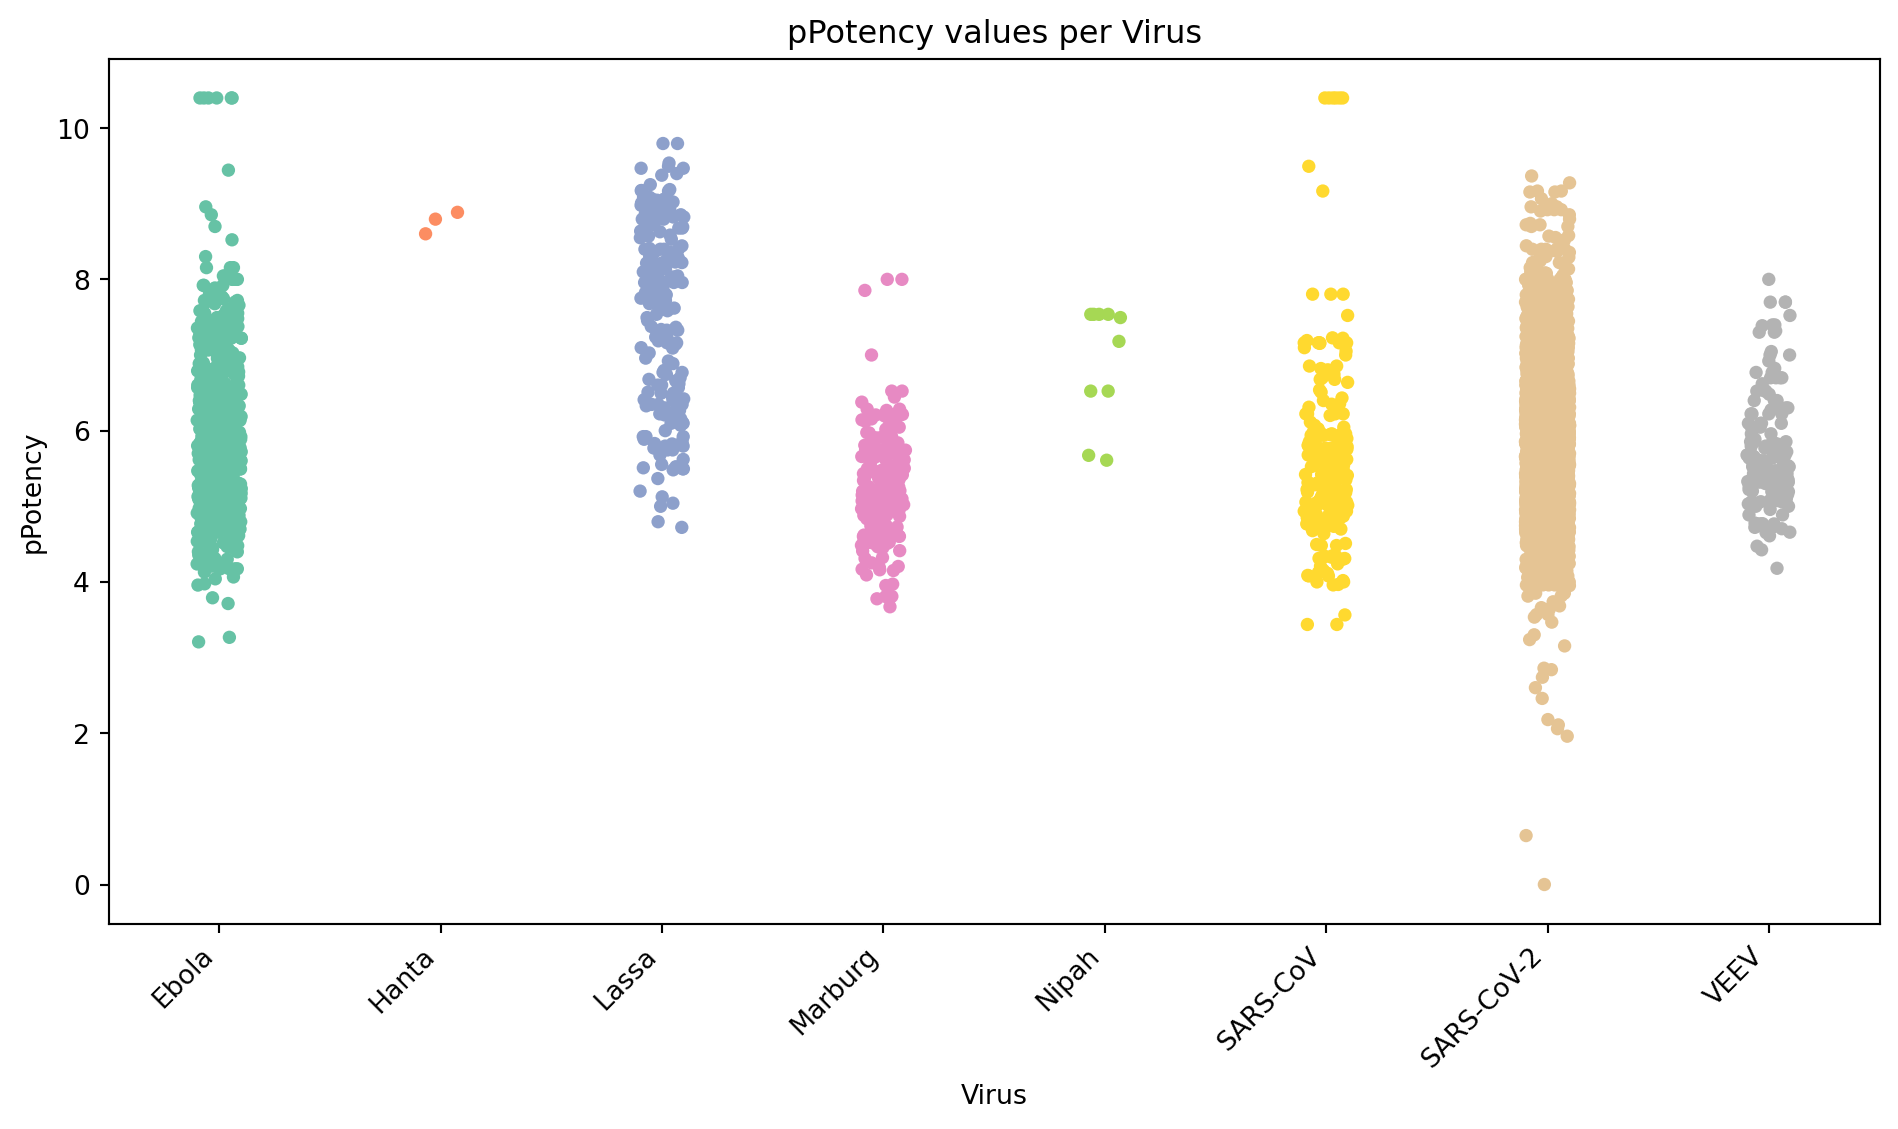

In [205]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=allVirusData_chEMBL_wMACAW_ordered,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [206]:
# df = allVirusData_chEMBL_wMACAW
Y = allVirusData_chEMBL_wMACAW.pPotency
smiles = allVirusData_chEMBL_wMACAW.Smiles

In [207]:
print(len(smiles))

4694


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

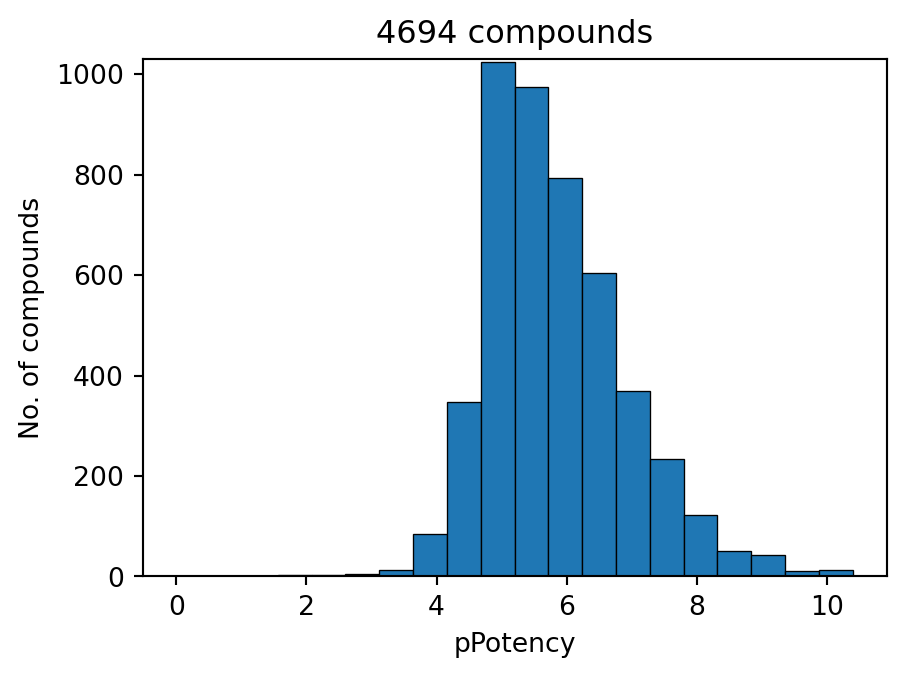

In [208]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [209]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [210]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [211]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [212]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 4694 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Test only results

In [213]:
%%time

from joblib import Parallel, delayed
from copy import deepcopy

# Step 1: Extract loop body into a function
def process_fold(fold_id, train_index, val_index, smiles, Y, mcw, param_grid):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_of_partitions}")
    
    smi_train = smiles.iloc[train_index]
    smi_val = smiles.iloc[val_index]
    y_train = Y[train_index]
    y_val = Y[val_index]
    
    # Compute MACAW embeddings (clone mcw to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_val = mcw_fold.transform(smi_val)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    # Test set predictions
    y_cv_pred = grid.predict(X_val)
    
    return y_cv_pred, y_val

# Step 2: Run in parallel
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(i+1, train_idx, val_idx, smiles, Y, mcw, param_grid)
    for i, (train_idx, val_idx) in enumerate(kf.split(smiles))
)

# Step 3: Combine results
Y_cv_pred = []
Y_obs = []
for y_pred, y_val in results:
    Y_cv_pred.extend(y_pred)
    Y_obs.extend(y_val)

print(f"Total predictions: {len(Y_cv_pred)}")

Total predictions: 4694
CPU times: user 2.01 s, sys: 1.17 s, total: 3.18 s
Wall time: 6min 27s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_CV_testOnly.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_CV_testOnly.png


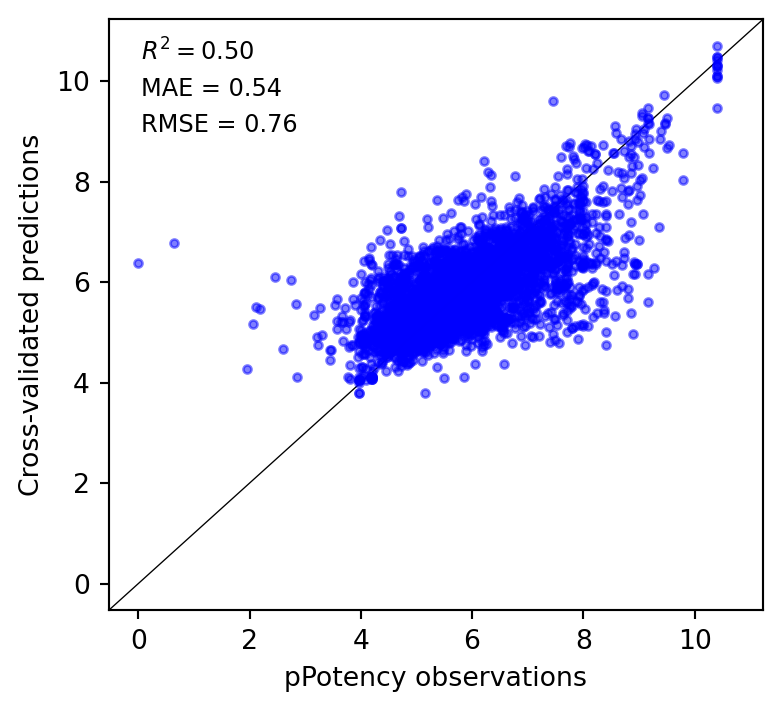

In [214]:
# Parity plot
parity_plot(x=Y_obs,
            y=Y_cv_pred, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'virus/allVirus_CV_testOnly.svg',
            save_formats=['svg', 'png'])  # Specify both formats

### ML predictions with Train + Test results

In [215]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.45
  RMSE: 0.66
  R²:   0.63
Test Set:
  MAE:  0.54
  RMSE: 0.76
  R²:   0.50

Best params (sample): [{'C': 5, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 30, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 30, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 1.97 s, sys: 1.2 s, total: 3.18 s
Wall time: 6min 26s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_CV_TrTs.png


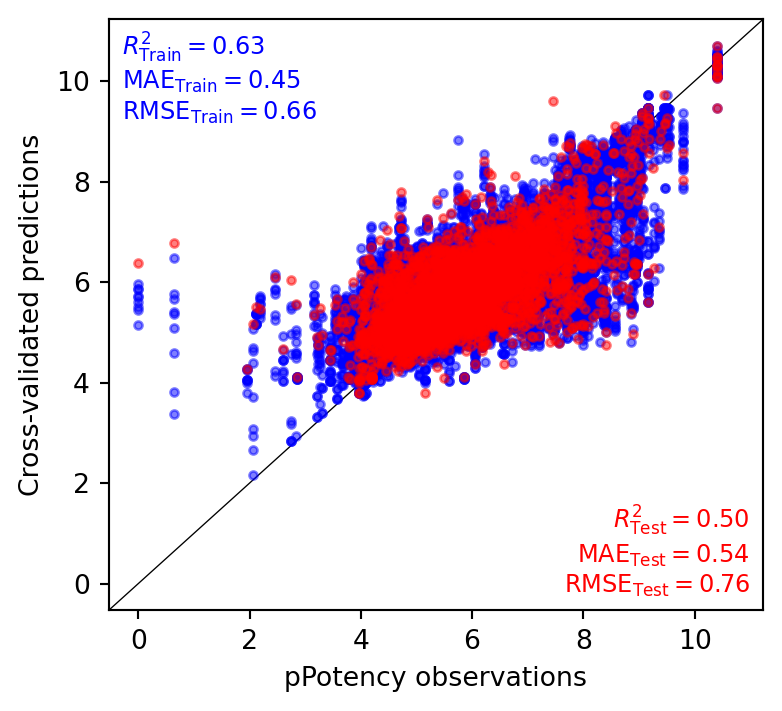

In [216]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'virus/allVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [217]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [218]:
X_all = mcw.transform(smiles)
X_all.shape

(4694, 15)

In [219]:
%%time
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error


# Configure parallelization
n_jobs = 4

# Optimize hyperparameters
regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,  # Get train scores too
    pre_dispatch='2*n_jobs'   # Control memory usage
)

print(f"Running GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_all, Y)

# Display results
print("\n" + "-"*40)
print("Best Hyperparameters:")
print("-"*40)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE: {-regr_pred.best_score_:.2f}")

# Train set predictions
y_pred = regr_pred.predict(X_all)

# Metrics
r2 = r2_score(Y, y_pred)
mae = mean_absolute_error(Y, y_pred)
rmse = np.sqrt(np.mean((Y - y_pred)**2))

print("\n" + "-"*40)
print("Training Set Performance:")
print("-"*40)
print(f"  R²:   {r2:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")

Running GridSearchCV with 4 parallel jobs...

----------------------------------------
Best Hyperparameters:
----------------------------------------
  C: 30
  epsilon: 0.1
  kernel: rbf

Best CV MAE: 0.61

----------------------------------------
Training Set Performance:
----------------------------------------
  R²:   0.65
  MAE:  0.42
  RMSE: 0.64
CPU times: user 3.36 s, sys: 169 ms, total: 3.53 s
Wall time: 52.5 s


Best params: {'C': 30, 'epsilon': 0.3, 'kernel': 'rbf'}
TEST  R²=0.397  MAE=0.73  RMSE=0.98
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_fullData_TrTs.png


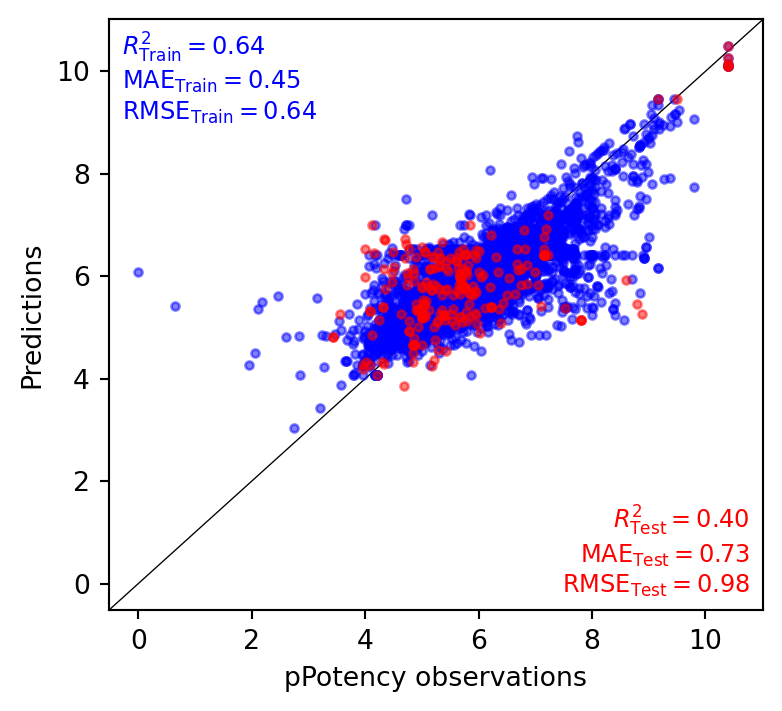

In [220]:
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

groups = allVirusData_chEMBL_wMACAW['VirusClassifier'].to_numpy()


# 1) split indices (group-aware if you supply groups)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idxTrain, idxTest = next(gss.split(smiles, Y, groups=groups) if groups is not None
                         else gss.split(smiles, Y))

smiTrain, smiTest = smiles.iloc[idxTrain], smiles.iloc[idxTest]
yTrain,   yTest   = Y[idxTrain], Y[idxTest]

# 2) fit MACAW on train only (avoid leakage)
mcw = MACAW(type_fp='atompairs', metric='sokal', n_components=15, n_landmarks=200, random_state=39)
mcw.fit(smiTrain, yTrain)
XTrain = mcw.transform(smiTrain)
XTest  = mcw.transform(smiTest)

# 3) tune SVR only on train (your param_grid)
regr = GridSearchCV(SVR(), param_grid=param_grid, cv=5, refit=True, n_jobs=4)
regr.fit(XTrain, yTrain)

# 4) evaluate on held-out test
yPred = regr.predict(XTest)
r2   = r2_score(yTest, yPred)
mae  = mean_absolute_error(yTest, yPred)
rmse = np.sqrt(np.mean((yTest - yPred)**2))

print("Best params:", regr.best_params_)
print(f"TEST  R²={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}")

# also get TRAIN predictions (note: these are IN-SAMPLE, not CV)
yPredTrain = regr.predict(XTrain)

# now call your parity_plot using Code-1 variables
parity_plot(
    x=yTrain,                # observed train
    y=yPredTrain,            # predicted train (in-sample)
    x_test=yTest,            # observed test
    y_test=yPred,            # predicted test
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'virus/allVirus_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)


### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2. Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [221]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


In [222]:
smi_lib = EnamineAntiviralsData.Smiles

Generate predictions for the H1 receptor:

In [223]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

Let us represent the predictions of both models:

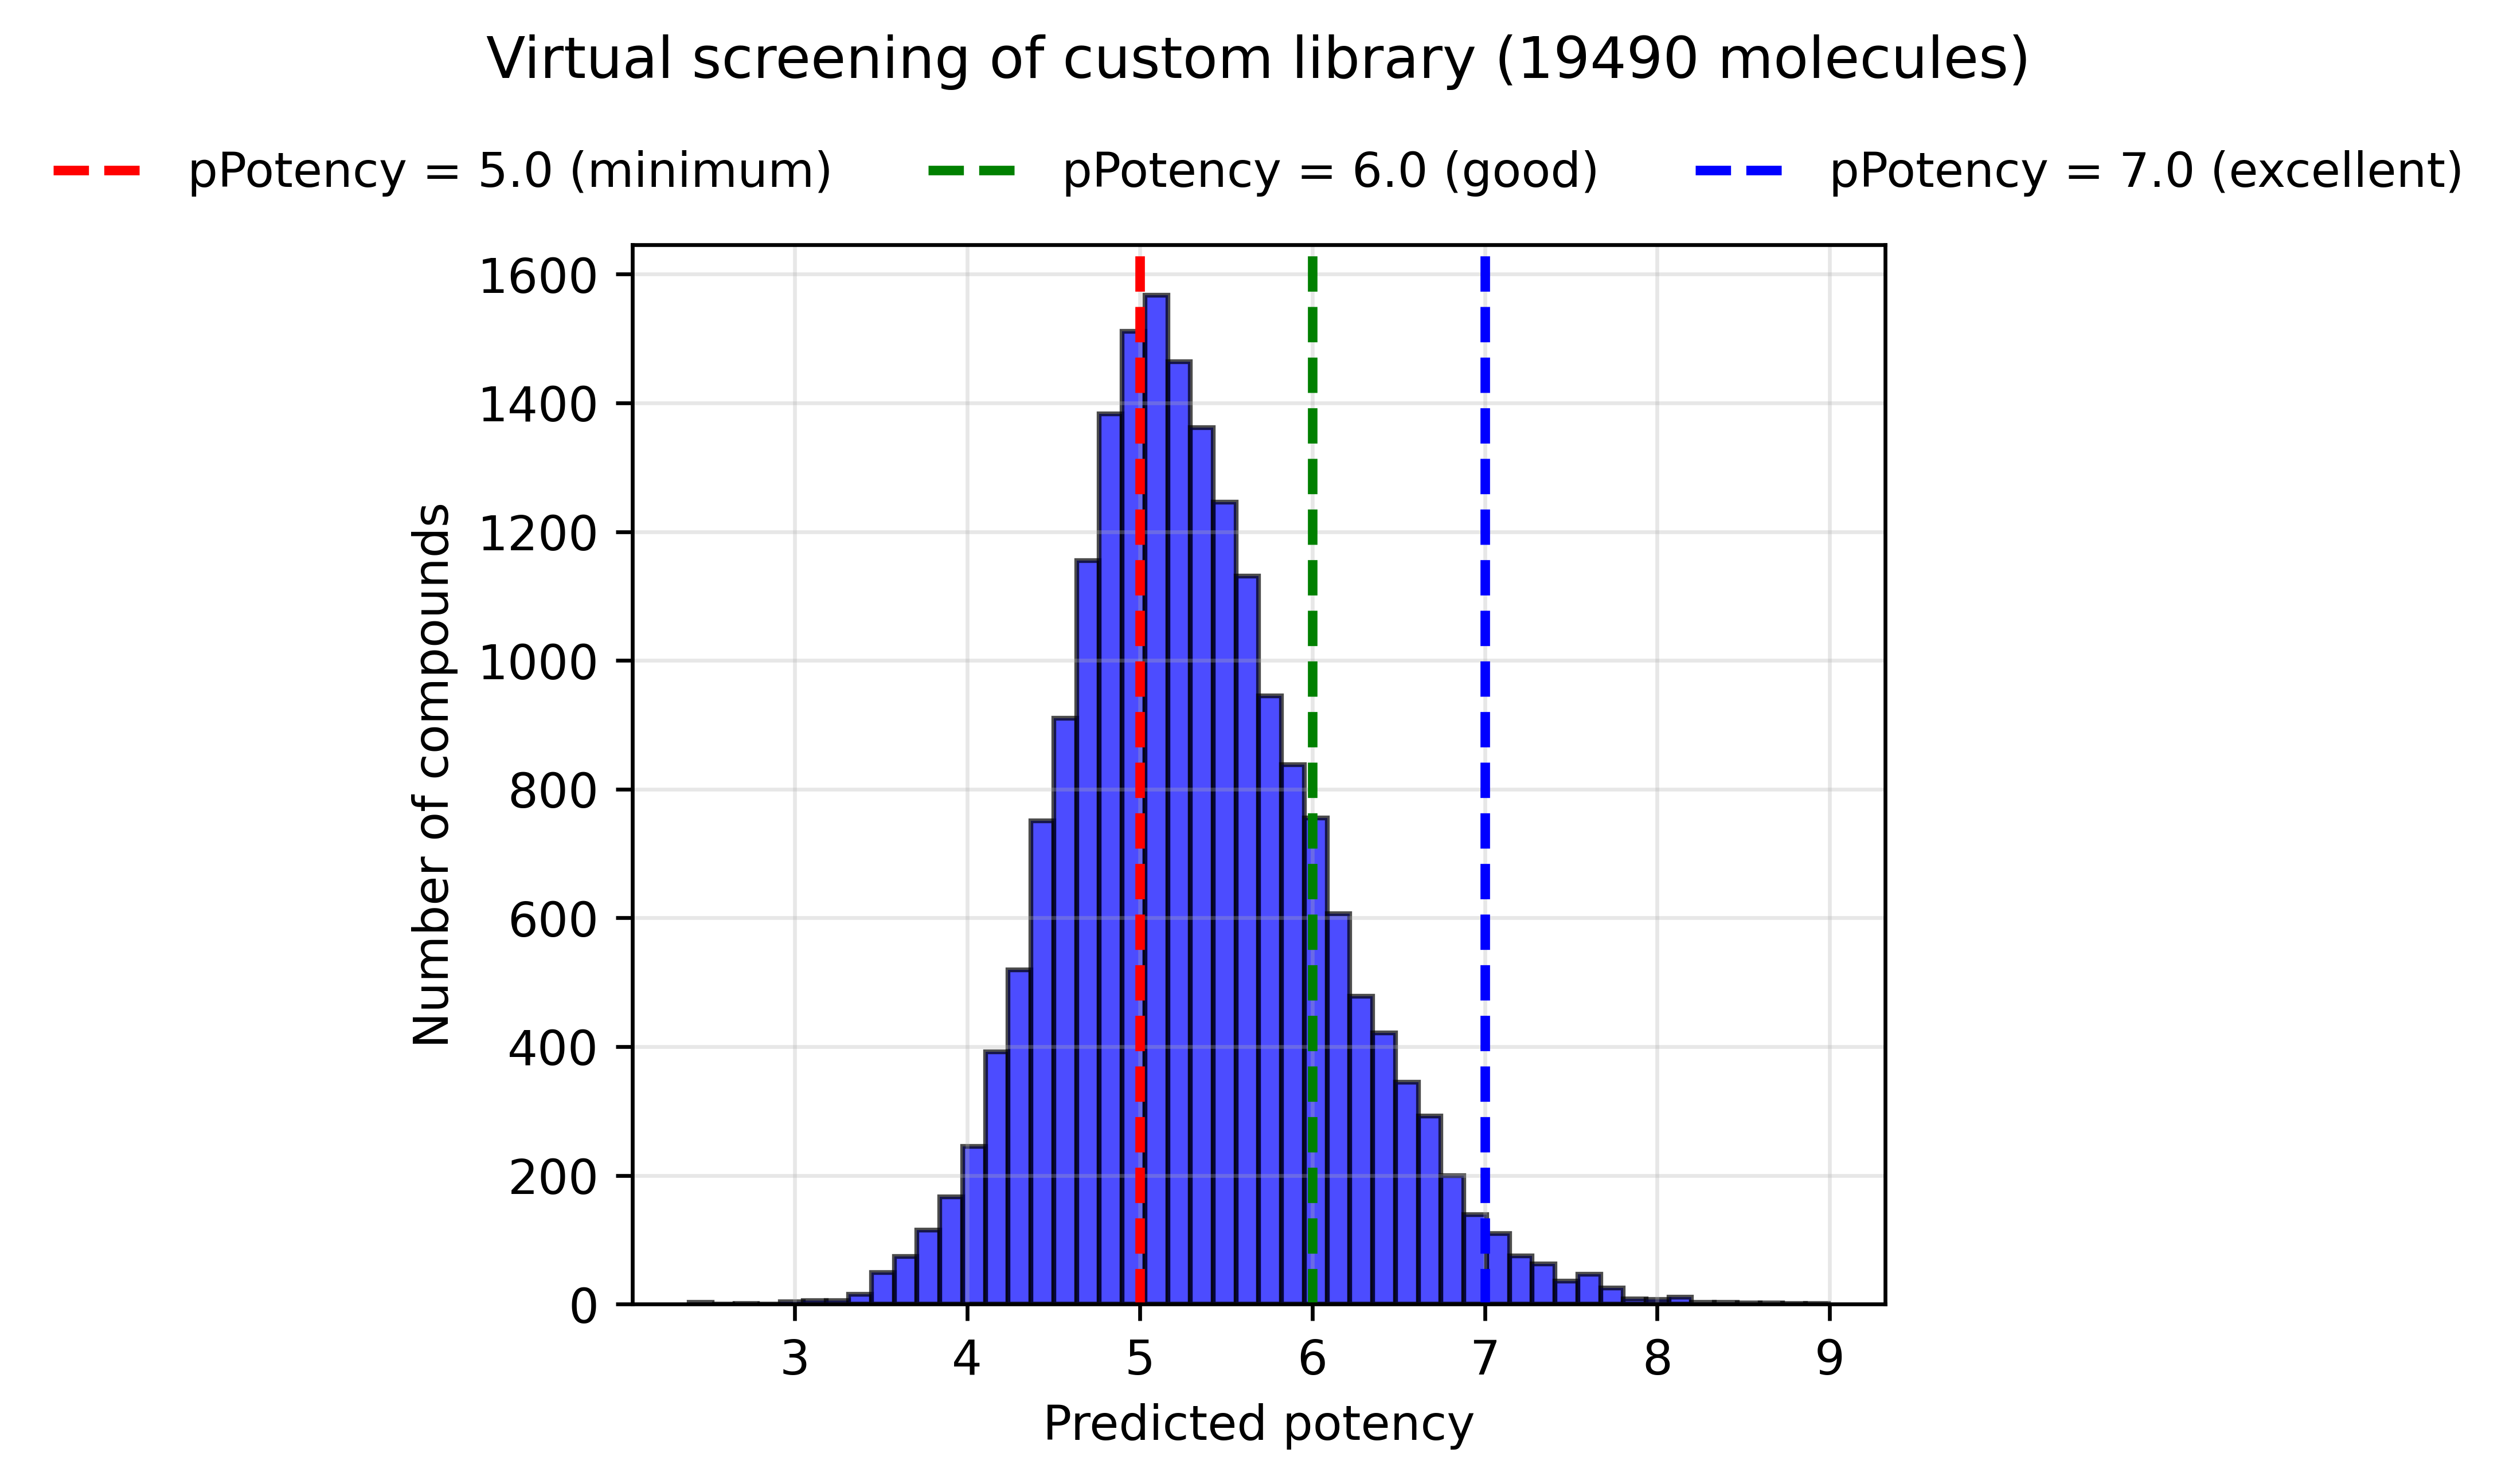

In [224]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'virus/allVirus_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [225]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 409 compounds
Medium priority (6 ≤ pPotency < 7.0): 2956 compounds
Low priority (5 ≤ pPotency < 6): 9187 compounds


In [226]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,Smiles,Source,pPotency_prediction
287,COCCn1c(nc2n(C)c(=O)[nH]c(=O)c12)N(C)Cc1ccccc1,Enamine_antivirals,7.088888
3237,Cn1cc(ccc1=O)C(=O)N1CCCC(C1)c1cc([nH]n1)C(F)(F)F,Enamine_DDS47,7.003066
3246,Cc1nn(C)c(C)c1c1cc([nH]n1)C(=O)N1CCc2c(F)ccc(F...,Enamine_DDS56,7.580994
3330,[O-][N+](=O)c1n[nH]cc1C(=O)N1CCC(C1)(c1nc(no1)...,Enamine_DDS140,7.008214
3349,CN1CCN(CC1)c1cc(CNC(=O)N2CCN(CC2)c2cccc(c2)C(F...,Enamine_DDS159,7.419963
...,...,...,...
19095,Cn1cc(C#N)cc1c1n(Cc2ccnc3ccc(Cl)cc23)nc2n(CC3C...,Enamine_Phenotypic,7.479230
19255,COCCOc1cc2ncnc(Nc3cccc(C#C)c3)c2cc1OCCOC,Enamine_Phenotypic,7.913260
19384,OC(=O)CCNc1cc(nc(n1)c1ccccn1)N1CCc2ccccc2CC1,Enamine_Phenotypic,7.204712
19450,COc1ccccc1N1CCN(CC1)C(=O)c1cc([nH]n1)c1ccc(F)cc1,Enamine_Phenotypic,7.862466


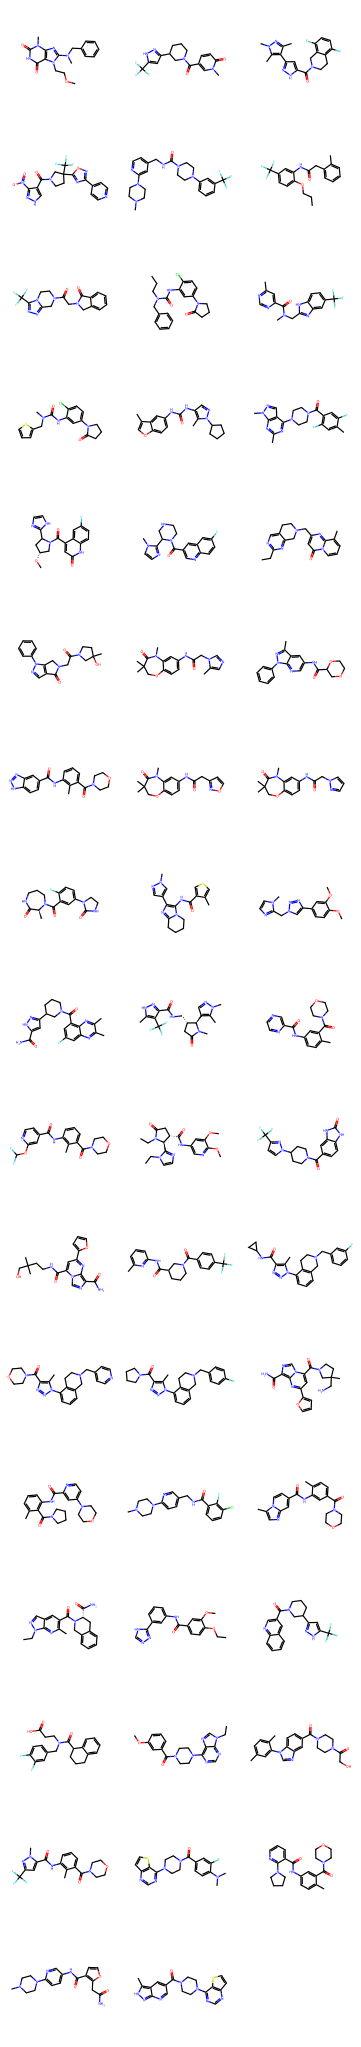

Partition 2/10
Partition 7/10
Partition 1/10
  Fold 1 - Train MAE: 0.52, Test MAE: 0.52
Partition 6/10
  Fold 6 - Train MAE: 0.38, Test MAE: 0.53
Partition 3/10
Partition 8/10
Partition 2/10
  Fold 2 - Train MAE: 0.42, Test MAE: 0.56
Partition 8/10
  Fold 8 - Train MAE: 0.49, Test MAE: 0.55
Partition 4/10
Partition 5/10
Partition 10/10
Partition 4/10
  Fold 4 - Train MAE: 0.48, Test MAE: 0.53
Partition 5/10
  Fold 5 - Train MAE: 0.41, Test MAE: 0.55
Partition 10/10
  Fold 10 - Train MAE: 0.47, Test MAE: 0.52
Partition 1/10
Partition 6/10
Partition 9/10
Partition 3/10
  Fold 3 - Train MAE: 0.46, Test MAE: 0.54
Partition 7/10
  Fold 7 - Train MAE: 0.47, Test MAE: 0.55
Partition 9/10
  Fold 9 - Train MAE: 0.41, Test MAE: 0.56


In [227]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

# Build feature matrix X and targets (regression + classification)

Train/valid split

Define the partitions for cross-validation.

Define hyperparameters for SVR:

Define MACAW embedding

Regression

### Evaluate cross validation performance

### Generate a model trained on the whole data set, to be used for prediction tasks

# Classification: Cross Validation loop

In [60]:
smiles = allVirusData_chEMBL_wMACAW["Smiles"].astype(str).reset_index(drop=True)
Y = allVirusData_chEMBL_wMACAW["pPotency"].to_numpy(dtype=np.float32)

# Ensure smiles is a pandas Series
if isinstance(smiles, np.ndarray):
    smiles = pd.Series(smiles)
if isinstance(Y, np.ndarray):
    Y = pd.Series(Y)

# Drop NaN or missing targets
validMaskY = Y.notna() & ~Y.isnull()
smiles = smiles[validMaskY].reset_index(drop=True)
Y = Y[validMaskY].reset_index(drop=True)

# Validate SMILES strings
validIdx = []
for i, s in enumerate(smiles):
    if isinstance(s, str) and len(s) > 0 and Chem.MolFromSmiles(s) is not None:
        validIdx.append(i)

smiles = smiles.iloc[validIdx].reset_index(drop=True)
Y = Y.iloc[validIdx].reset_index(drop=True)

print(f" Cleaned data has: {len(smiles)} valid samples after dropping NaN targets and invalid SMILES.")
print(f"Example indices: {Y.index[:10].tolist()}")

 Cleaned data has: 4694 valid samples after dropping NaN targets and invalid SMILES.
Example indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [61]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

In [62]:
# For classification we use SVC with RBF; only C is tuned here (gamma='scale' default)
param_grid_cls = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'kernel': ['rbf']
}

### Classification with Morgan (ECFP6) + RandomForest

In [63]:
%%time

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Helpers
# ---------------------------
def morganBits(smilesList, nBits=2048, radius=3):
    """Return (X, validMask) where X is [n_valid, nBits] uint8 array of ECFP bits."""
    fps = []
    validMask = []
    for s in smilesList:
        mol = Chem.MolFromSmiles(s) if isinstance(s, str) else None
        if mol is None:
            validMask.append(False)
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=np.uint8)
        # NOTE: RDKit DataStructs is optional here; ConvertToNumpyArray handles directly if imported.
        # To avoid extra import, we iterate bits:
        onBits = list(fp.GetOnBits())
        arr[onBits] = 1
        fps.append(arr)
        validMask.append(True)
    if len(fps) == 0:
        return np.zeros((0, nBits), dtype=np.uint8), np.array(validMask, dtype=bool)
    return np.vstack(fps), np.array(validMask, dtype=bool)

def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# ---------------------------
# Prepare data
# ---------------------------
DF = allVirusData_chEMBL_wMACAW  
assert {"Smiles", "VirusClassifier"}.issubset(DF.columns), "Expected Smiles and VirusClassifier in DF."

smilesSeries = DF["Smiles"].astype(str).reset_index(drop=True)
labelsStr = DF["VirusClassifier"].astype(str).reset_index(drop=True)

# Encode string labels to ints (for modeling), but we will report strings
labelEncoder = LabelEncoder()
yEncAll = labelEncoder.fit_transform(labelsStr)

# Compute Morgan fingerprints and filter invalids
XAllBits, validMask = morganBits(smilesSeries.tolist(), nBits=2048, radius=3)
yEncAllValid = yEncAll[validMask]
labelsStrValid = labelsStr[validMask].reset_index(drop=True)

if XAllBits.shape[0] < 10:
    raise RuntimeError(f"Too few valid molecules after featurization: {XAllBits.shape[0]}")

print(f"[Info] Valid training molecules: {XAllBits.shape[0]} / {len(smilesSeries)}")

# ---------------------------
# Nested CV (outer stratified K-fold, inner grid search)
# ---------------------------
numOfPartitions = 10
kfOuter = StratifiedKFold(n_splits=numOfPartitions, shuffle=True, random_state=42)

paramGridCls = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]  # handle imbalance
}

YcvPredCls, YobsCls, bestParamsPerFold = [], [], []
foldId = 1
for trainIndex, valIndex in kfOuter.split(XAllBits, yEncAllValid):
    print(f"Partition {foldId}/{kfOuter.get_n_splits()}")
    foldId += 1

    XTrain, XVal = XAllBits[trainIndex], XAllBits[valIndex]
    yTrainEnc, yValEnc = yEncAllValid[trainIndex], yEncAllValid[valIndex]
    yValStr = labelEncoder.inverse_transform(yValEnc)

    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gridCls = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=paramGridCls,
        scoring="f1_macro",
        cv=inner,
        n_jobs=4,
        refit=True,
        verbose=0
    )
    gridCls.fit(XTrain, yTrainEnc)
    bestParamsPerFold.append(gridCls.best_params_)

    yPredEnc = gridCls.predict(XVal)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)

    YcvPredCls.extend(yPredStr.tolist())
    YobsCls.extend(yValStr.tolist())

[Info] Valid training molecules: 4694 / 4694
Partition 1/10
Partition 2/10
Partition 3/10
Partition 4/10
Partition 5/10
Partition 6/10
Partition 7/10
Partition 8/10
Partition 9/10
Partition 10/10
CPU times: user 2min 20s, sys: 9.08 s, total: 2min 29s
Wall time: 46min 16s


### Cross Validation metrics

In [64]:
f1Cv  = f1_score(YobsCls, YcvPredCls, average="macro")
baCv  = balanced_accuracy_score(YobsCls, YcvPredCls)
accCv = accuracy_score(YobsCls, YcvPredCls)
print(f"[Nested-CV] Classification | F1-macro: {f1Cv:.3f} | Balanced Acc: {baCv:.3f} | Acc: {accCv:.3f}")
print(f"[Info] Best params (sample): {bestParamsPerFold[:3]}")

[Nested-CV] Classification | F1-macro: 0.581 | Balanced Acc: 0.723 | Acc: 0.813
[Info] Best params (sample): [{'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}, {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}]


### Cross Validation Confusion Matrix

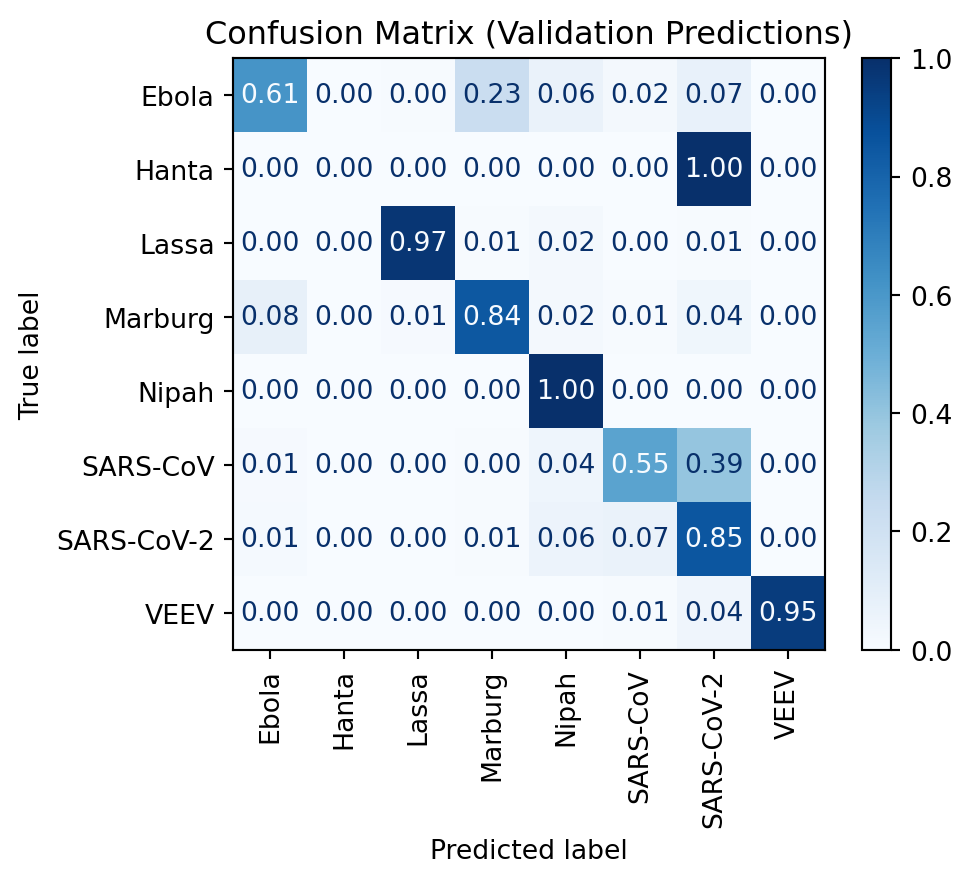

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

yTrue = YobsCls   # true labels (strings)
yPred = YcvPredCls  # predicted labels (strings)

cm = confusion_matrix(yTrue, yPred, labels=np.unique(yTrue), normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yTrue))
disp.plot(xticks_rotation='vertical', cmap='Blues', values_format='.2f')
plt.title("Confusion Matrix (Validation Predictions)")
plt.savefig(resultsDir + 'virus/allVirus_CV_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_CV_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Cross Validation Per-class precision/recall/F1 values

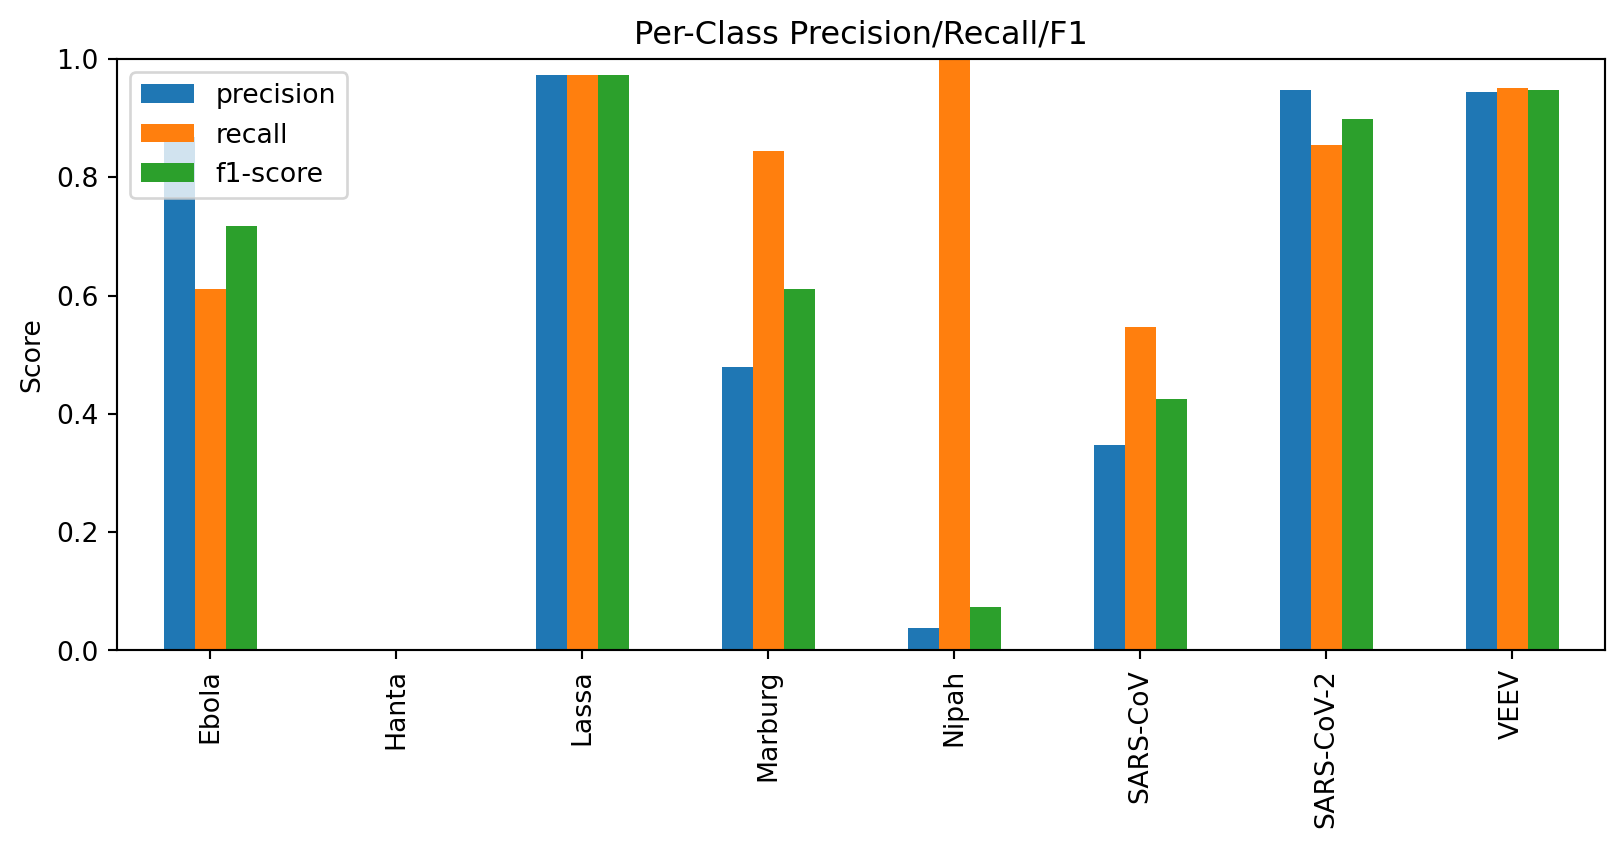

In [66]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(yTrue, yPred, output_dict=True)
reportDF = pd.DataFrame(report).T.iloc[:-3]  # remove avg rows
reportDF[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,4))
plt.title("Per-Class Precision/Recall/F1")
plt.ylabel("Score")
plt.ylim(0,1)
plt.savefig(resultsDir + 'virus/allVirus_CV_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_CV_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Refit on ALL valid data

In [67]:
finalGrid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=paramGridCls,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True,
    verbose=0
)
finalGrid.fit(XAllBits, yEncAllValid)
finalCls = finalGrid.best_estimator_
print(f"[Refit-All] Best params: {finalGrid.best_params_}")

[Refit-All] Best params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 800}


### In-sample metrics on ALL valid

In [68]:
yAllPredEnc = finalCls.predict(XAllBits)
yAllPredStr = labelEncoder.inverse_transform(yAllPredEnc)
print(f"[Refit-All] F1-macro (train): {f1_score(labelsStrValid, yAllPredStr, average='macro'):.3f}")
print(f"[Refit-All] Balanced Acc (train): {balanced_accuracy_score(labelsStrValid, yAllPredStr):.3f}")
print(f"[Refit-All] Accuracy (train): {accuracy_score(labelsStrValid, yAllPredStr):.3f}")

[Refit-All] F1-macro (train): 0.750
[Refit-All] Balanced Acc (train): 0.913
[Refit-All] Accuracy (train): 0.848


### Confusion Matrix

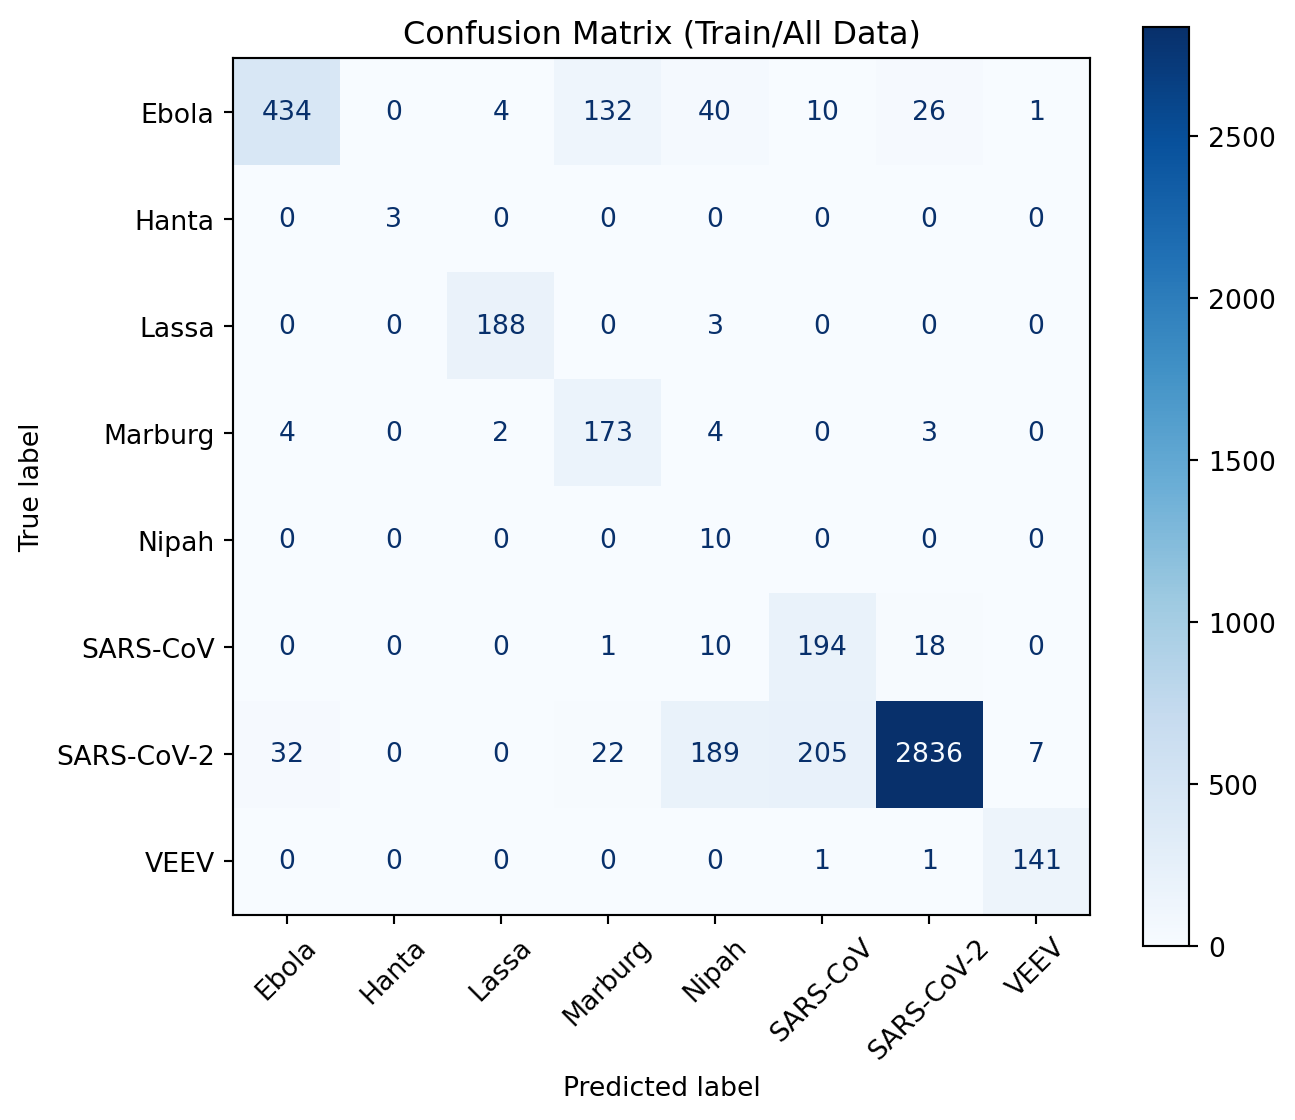

In [69]:
# --- Predictions on ALL (in-sample) ---
yPredEnc = finalCls.predict(XAllBits)

# Class labels (strings) for display
if 'labelEncoder' in globals():
    displayLabels = labelEncoder.classes_
    yTrueStr = labelEncoder.inverse_transform(yEncAllValid)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)
else:
    # fallback: show encoded ints if no encoder is available
    displayLabels = finalCls.classes_
    yTrueStr = yEncAllValid
    yPredStr = yPredEnc


cm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix (Train/All Data)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

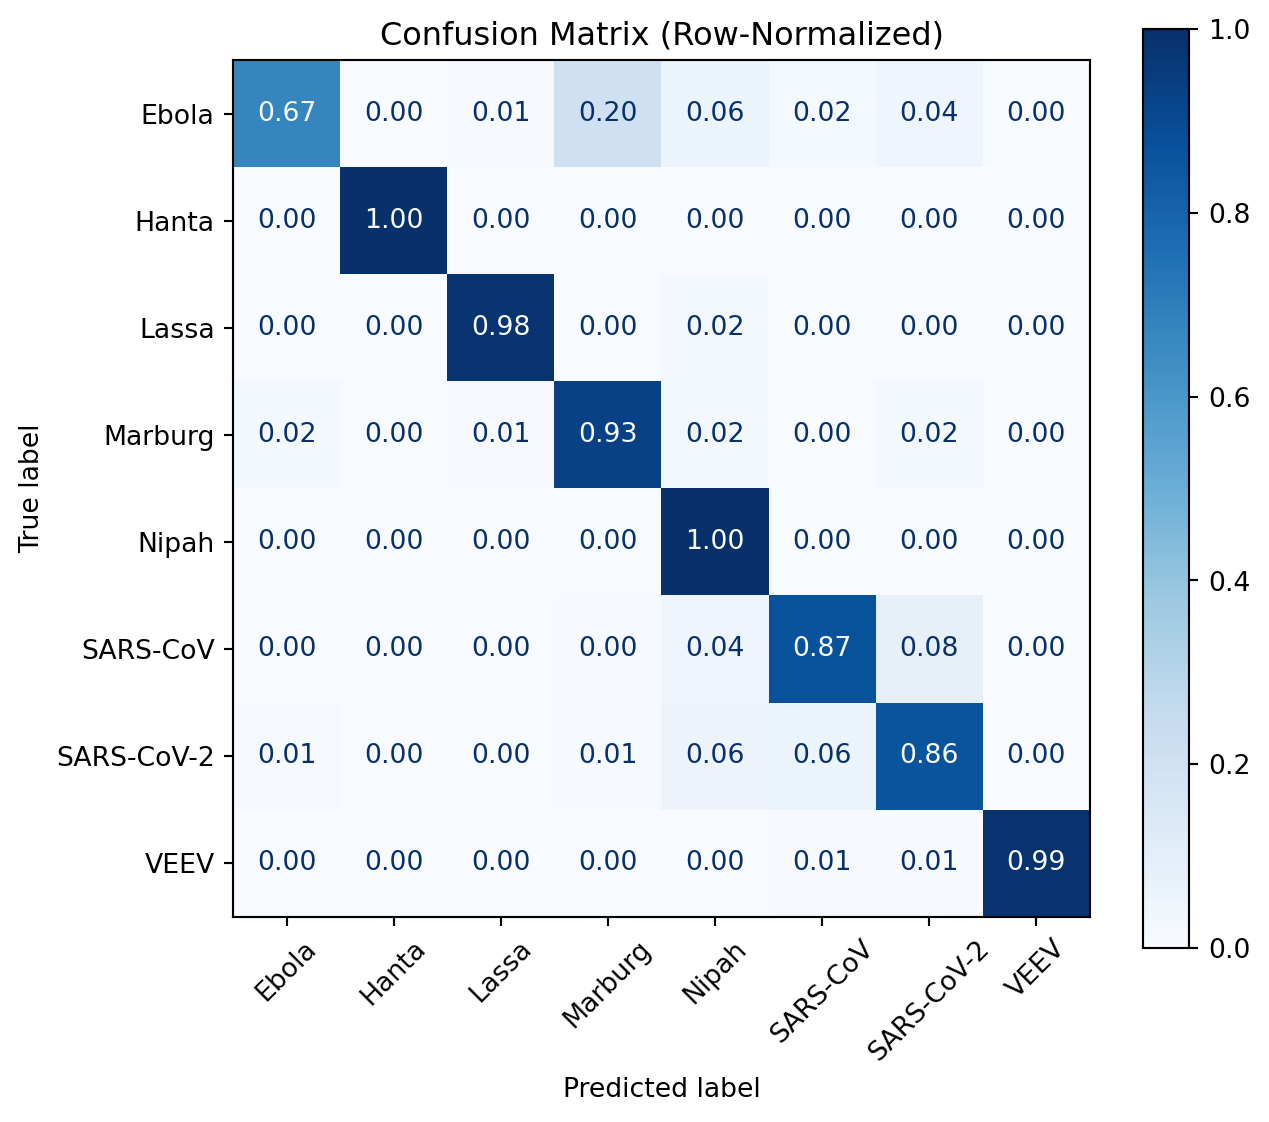

In [70]:
# Confusion matrix (row-normalized by true class)
cm_norm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp_norm.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True, values_format=".2f")
ax.set_title("Confusion Matrix (Row-Normalized)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(resultsDir + 'virus/allVirus_fullData_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_fullData_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Per-class precision/recall/F1 values

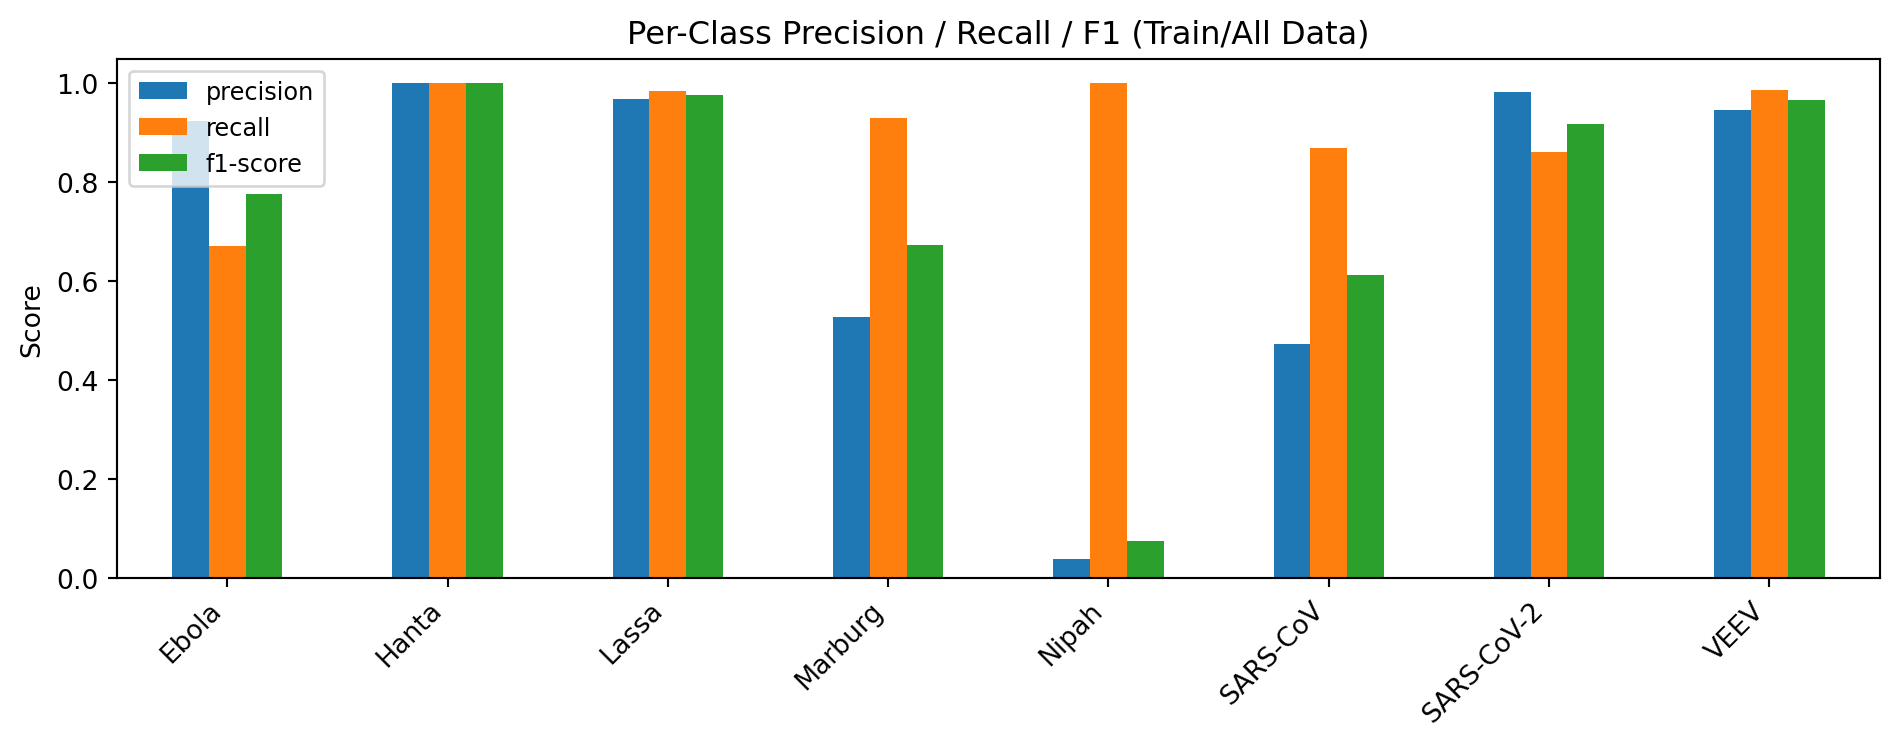

In [71]:
report = classification_report(yTrueStr, yPredStr, target_names=displayLabels, output_dict=True)
rep_df = pd.DataFrame(report).T.loc[displayLabels, ["precision", "recall", "f1-score"]]

ax = rep_df.plot(kind="bar", figsize=(10,4))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1 (Train/All Data)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(resultsDir + 'virus/allVirus_fullData_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_fullData_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

# Validation

In [72]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


Keep SMILES as strings

In [73]:
smi_enamine = EnamineAntiviralsData["Smiles"].astype(str).reset_index(drop=False)  # keeps 'index' column

Validate SMILES with RDKit

In [74]:
valid_mask = smi_enamine["Smiles"].apply(lambda s: Chem.MolFromSmiles(s) is not None).to_numpy()
valid_rows = smi_enamine.loc[valid_mask, "index"].to_numpy()
smi_valid  = smi_enamine.loc[valid_mask, "Smiles"].tolist()

print(f"[Enamine] valid molecular smiles: {len(smi_valid)} / {len(smi_enamine)}")

[Enamine] valid molecular smiles: 19490 / 19490


Regression on pPotency data

In [78]:
# MACAW features for Enamine (regression head)
X_enamine_reg = mcw.transform(smi_valid)

# Predict potency
Y_enamine_pred = regr_pred.predict(X_enamine_reg)  # regrPred = best GridSearchCV or best estimator

Plot the results

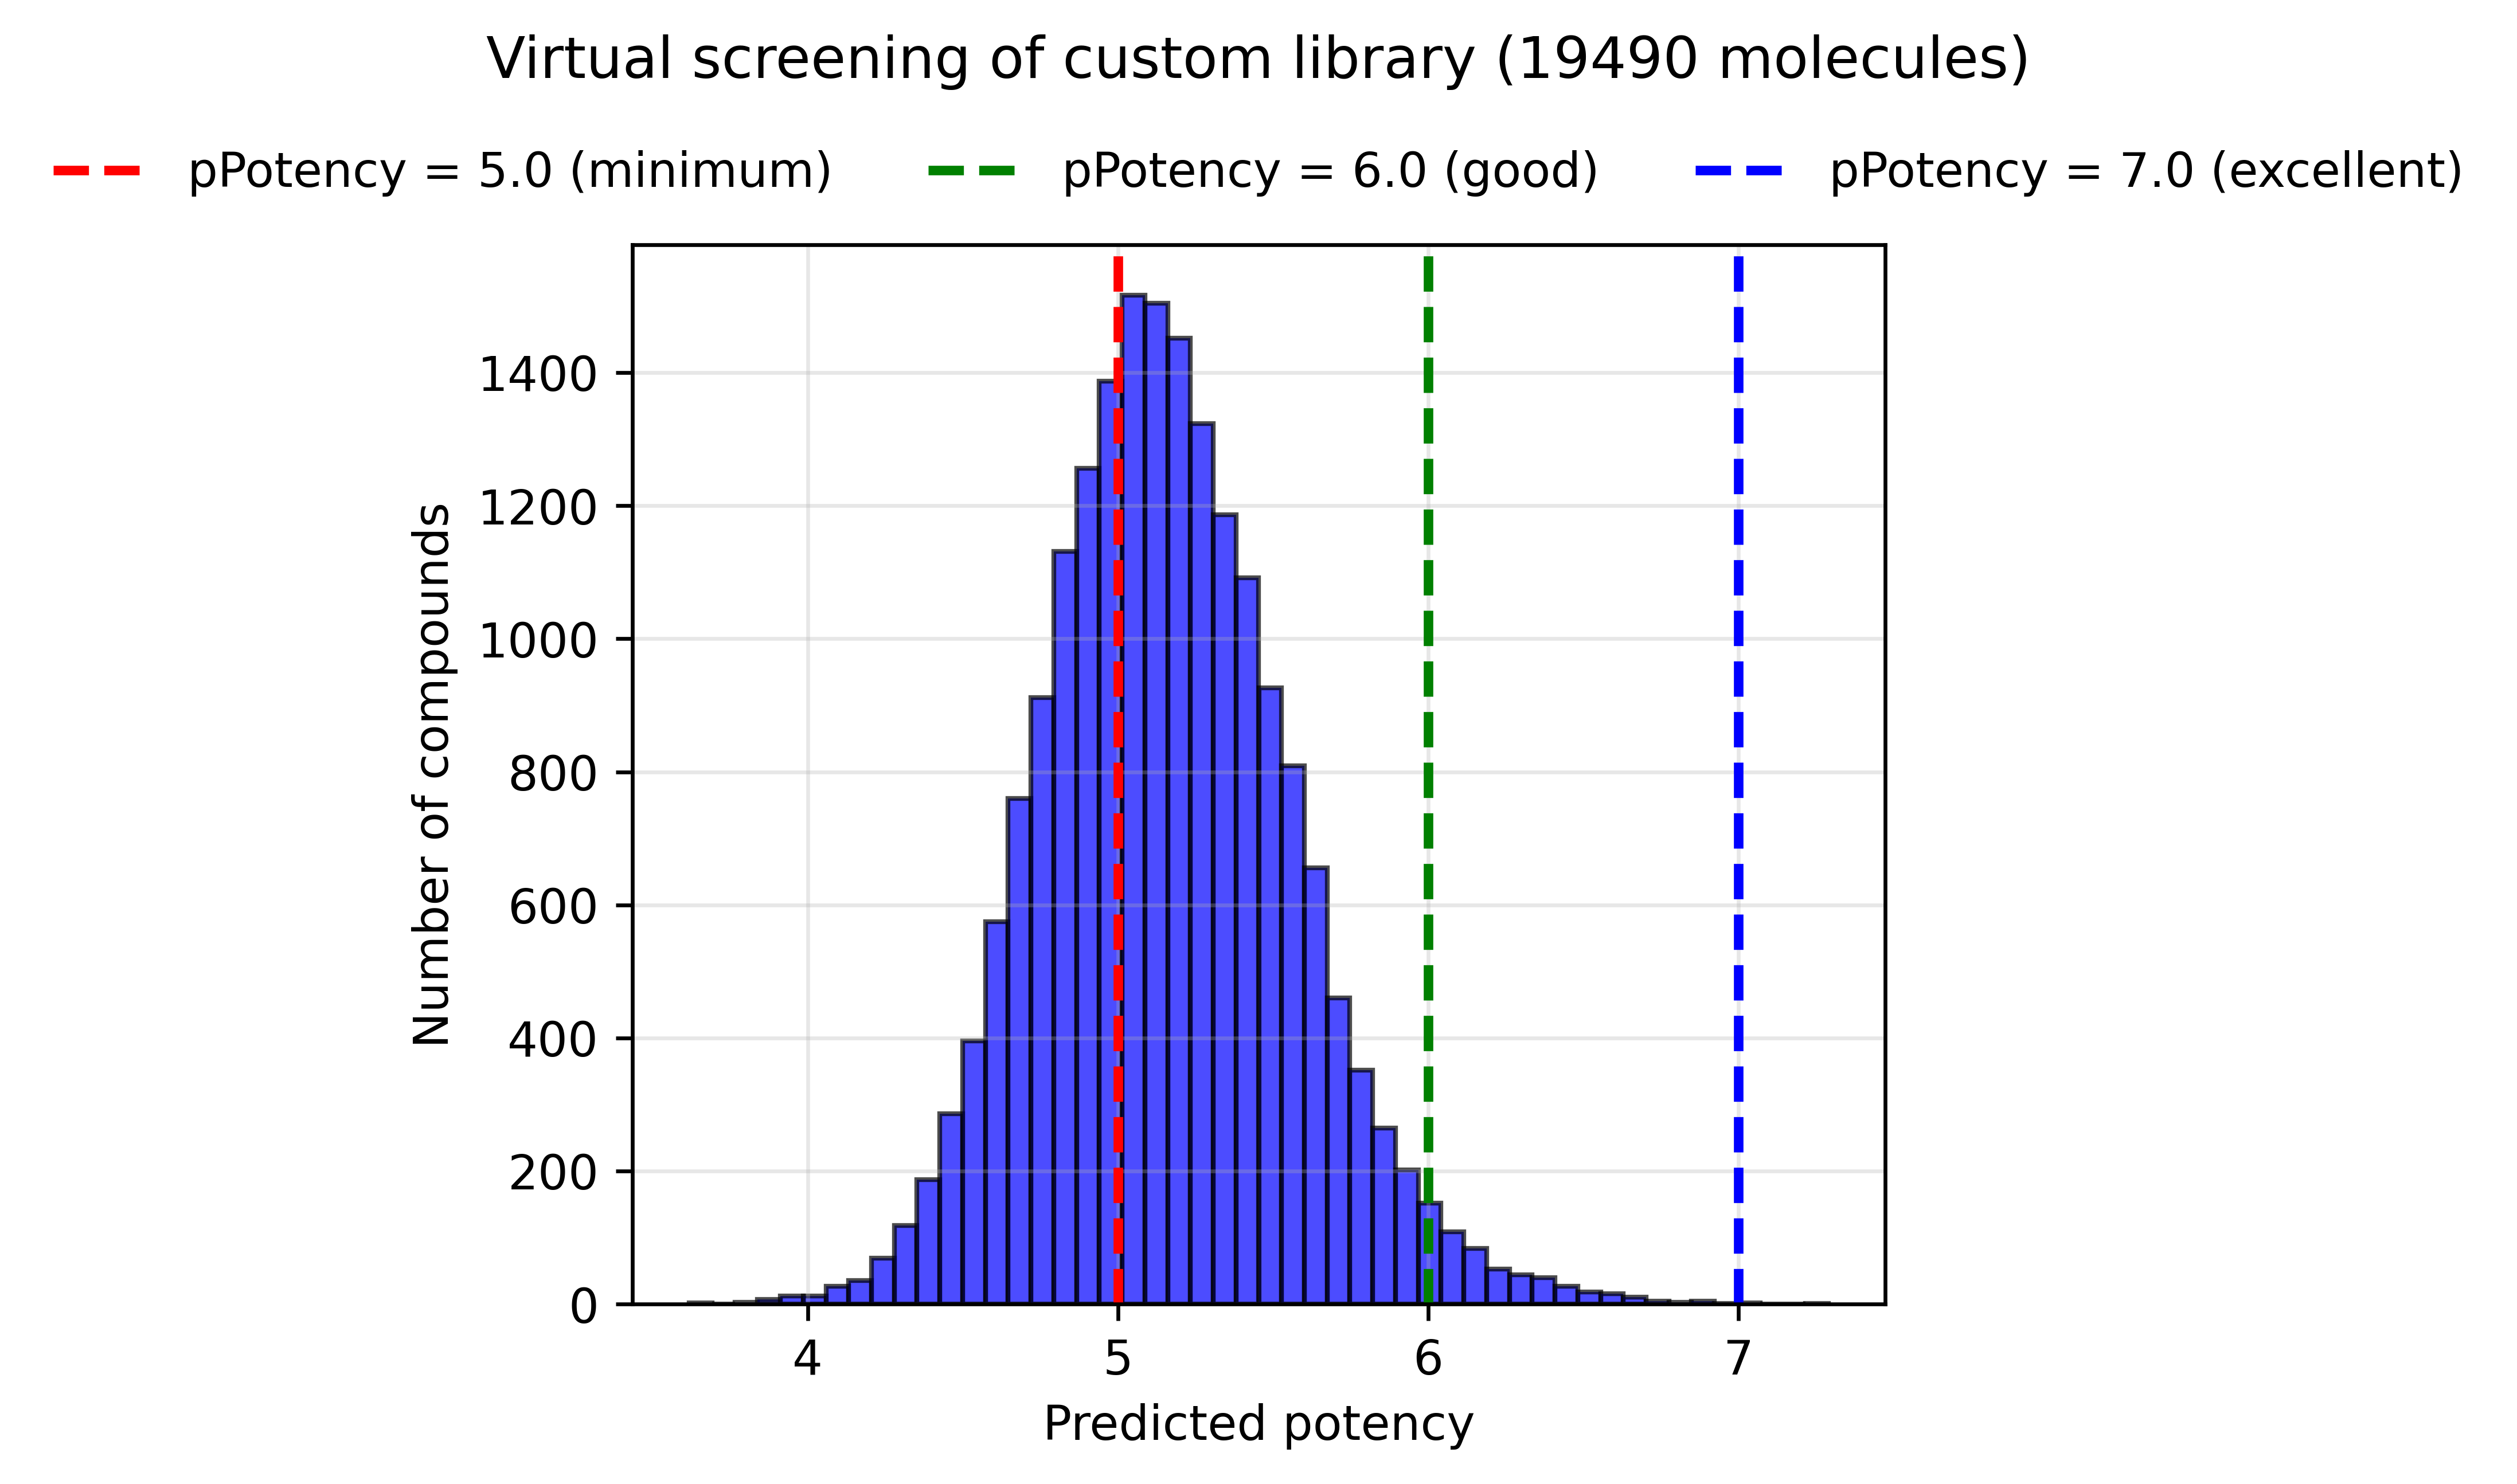

In [81]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y_enamine_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'virus/allVirus_validation_Reg.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_validation_Reg.png', bbox_inches='tight', dpi=300)
plt.show()

In [84]:
# Define multiple priority levels
high_priority_idx = np.where(Y_enamine_pred >= 7)[0]
medium_priority_idx = np.where((Y_enamine_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y_enamine_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 3 compounds
Medium priority (6 ≤ pPotency < 7.0): 493 compounds
Low priority (5 ≤ pPotency < 6): 12088 compounds


In [85]:
EnamineAntiviralsData_final_Reg = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final_Reg['pPotency_prediction'] = Y_enamine_pred[idx]

EnamineAntiviralsData_final_Reg

,Smiles,Source,pPotency_prediction
4865,OC1Cc2ccccc2C1NC(=O)C1CCNC(=O)C1,Enamine_DDS1675,7.066303
16348,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic,7.290395
18443,C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc34)[C@@H]1CC...,Enamine_Phenotypic,7.067511


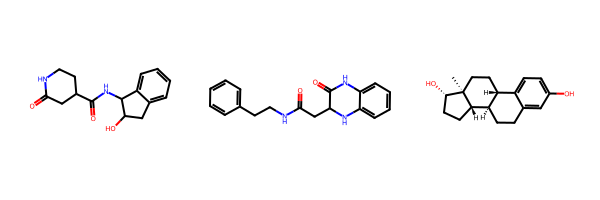

In [86]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_Reg.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Classification task Enamine dataset

In [87]:
from rdkit.Chem import AllChem

def morganBits(smilesList, nBits=2048, radius=3):
    X = np.zeros((len(smilesList), nBits), dtype=np.uint8)
    for i, s in enumerate(smilesList):
        m = Chem.MolFromSmiles(s)
        if m is None: 
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=radius, nBits=nBits)
        X[i, list(fp.GetOnBits())] = 1
    return X

X_enamine_cls = morganBits(smi_valid, nBits=2048, radius=3)

Predict class probabilities

In [88]:
# Predict probabilities and top-1 / top-3
proba = finalCls.predict_proba(X_enamine_cls)       # [n_valid, n_classes]
top1 = np.argmax(proba, axis=1)

# classes as strings
classes_str = labelEncoder.classes_ if "labelEncoder" in globals() else finalCls.classes_
predVirus_valid = classes_str[top1]
predVirusConf_valid = proba[np.arange(len(top1)), top1]

# Top-3 labels + probs (nice for triage)
top3_idx = np.argsort(-proba, axis=1)[:, :3]
predVirusTop3_valid = []
predVirusTop3Proba_valid = []
for r in range(top3_idx.shape[0]):
    labels3 = classes_str[top3_idx[r]]
    probs3 = [f"{labels3[j]}:{proba[r, top3_idx[r][j]]:.2f}" for j in range(len(labels3))]
    predVirusTop3_valid.append(", ".join(labels3))
    predVirusTop3Proba_valid.append(", ".join(probs3))


Assemble results in a table

In [89]:
def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# Start with a copy of the valid subset rows
EnamineAntiviralsData_final_Cls = EnamineAntiviralsData.iloc[valid_rows].copy()

# Attach regression (potency)
safeInsert(EnamineAntiviralsData_final_Cls, 0, "pred_pPotency", np.round(Y_enamine_pred, 3))

# Attach classification (virus)
safeInsert(EnamineAntiviralsData_final_Cls, 1, "predVirus", predVirus_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 2, "predVirusConf", np.round(predVirusConf_valid, 3))
safeInsert(EnamineAntiviralsData_final_Cls, 3, "predVirusTop3", predVirusTop3_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 4, "predVirusTop3Proba", predVirusTop3Proba_valid)

# Optional: composite rank for prioritization
alpha, beta = 1.0, 0.5
rankScore = alpha * EnamineAntiviralsData_final_Cls["pred_pPotency"].to_numpy() + \
            beta  * EnamineAntiviralsData_final_Cls["predVirusConf"].to_numpy()
safeInsert(EnamineAntiviralsData_final_Cls, 5, "rankScore", np.round(rankScore, 3))

print("[Enamine] final shape:", EnamineAntiviralsData_final_Cls.shape)
EnamineAntiviralsData_final_Cls.head()

[Enamine] final shape: (19490, 8)


,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
0,4.966,SARS-CoV-2,0.427,"SARS-CoV-2, Ebola, SARS-CoV","SARS-CoV-2:0.43, Ebola:0.18, SARS-CoV:0.17",5.180,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,5.174,SARS-CoV-2,0.477,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.48, SARS-CoV:0.23, Ebola:0.13",5.413,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,4.819,SARS-CoV-2,0.441,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.44, SARS-CoV:0.19, Ebola:0.16",5.040,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,5.217,SARS-CoV-2,0.372,"SARS-CoV-2, Ebola, SARS-CoV","SARS-CoV-2:0.37, Ebola:0.20, SARS-CoV:0.17",5.403,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,4.999,SARS-CoV-2,0.429,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.20, Ebola:0.14",5.214,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


Filter for pred_pPotency >= 7.0

In [90]:
EnamineAntiviralsData_final_pPotency = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['pred_pPotency'] >= 7.0
]
EnamineAntiviralsData_final_pPotency

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
4865,7.066,SARS-CoV-2,0.486,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.49, SARS-CoV:0.18, Ebola:0.14",7.309,OC1Cc2ccccc2C1NC(=O)C1CCNC(=O)C1,Enamine_DDS1675
16348,7.290,SARS-CoV-2,0.427,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.18, Ebola:0.17",7.504,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic
18443,7.068,SARS-CoV-2,0.417,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.42, SARS-CoV:0.22, Ebola:0.15",7.276,C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc34)[C@@H]1CC...,Enamine_Phenotypic


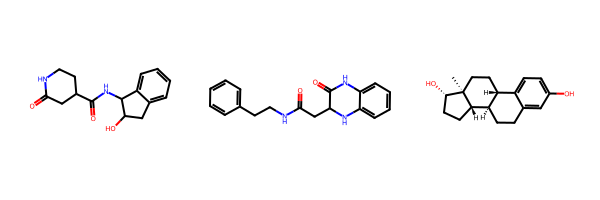

In [91]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_pPotency.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.0
 
 **rankScore=α×pred_pPotency+β×predVirusConf** (α = 1.0, β = 0.5)

* ≥ 7.5	--> Very promising (strong potency + good confidence)
* 7.0–7.5 -->	Potent hits, moderate confidence
* 6.0–7.0 -->	Potentially interesting, lower confidence or moderate potency
* < 6.0	--> Weak activity or uncertain classification

In [92]:
EnamineAntiviralsData_final_rankScore = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.0
]
EnamineAntiviralsData_final_rankScore

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
3442,6.852,SARS-CoV-2,0.373,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.37, SARS-CoV:0.22, Ebola:0.17",7.038,OC(=O)C1CC(NC(=O)C2CCOC2)c2ccccc12,Enamine_DDS252
4865,7.066,SARS-CoV-2,0.486,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.49, SARS-CoV:0.18, Ebola:0.14",7.309,OC1Cc2ccccc2C1NC(=O)C1CCNC(=O)C1,Enamine_DDS1675
4896,6.944,SARS-CoV-2,0.468,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.47, SARS-CoV:0.23, Ebola:0.13",7.178,CC(=O)NC(CC(=O)NC1C(O)Cc2ccccc12)c1ccccc1,Enamine_DDS1706
5989,6.874,SARS-CoV-2,0.422,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.42, SARS-CoV:0.21, Ebola:0.13",7.085,CC(C)C(=O)N1C[C@H]([C@@H](C1)c1ccccc1)C(=O)O,Enamine_DDS2799
6504,6.820,SARS-CoV-2,0.381,"SARS-CoV-2, Ebola, SARS-CoV","SARS-CoV-2:0.38, Ebola:0.19, SARS-CoV:0.18",7.010,OC1Cc2ccccc2C1NC(=O)NCCNC(=O)c1ccco1,Enamine_DDS3314
7223,6.922,SARS-CoV-2,0.450,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.45, SARS-CoV:0.27, Ebola:0.11",7.147,C[C@@H](NC(=O)N[C@@H]1C[C@H]1c1ccco1)c1ccc(F)cc1,Enamine_DDS4033
8016,6.894,SARS-CoV-2,0.491,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.49, SARS-CoV:0.23, Ebola:0.13",7.140,OC(=O)C[C@H](NC(=O)C1CCS(=O)(=O)N1)c1ccc2ccccc2c1,Enamine_DDS4826
16348,7.290,SARS-CoV-2,0.427,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.18, Ebola:0.17",7.504,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic
18358,6.771,SARS-CoV-2,0.520,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.52, SARS-CoV:0.16, Ebola:0.16",7.031,CCCCc1c(C)nc2nc(SCc3nc4n(CCCC)c(=O)[nH]c(=O)c4...,Enamine_Phenotypic
18443,7.068,SARS-CoV-2,0.417,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.42, SARS-CoV:0.22, Ebola:0.15",7.276,C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc34)[C@@H]1CC...,Enamine_Phenotypic


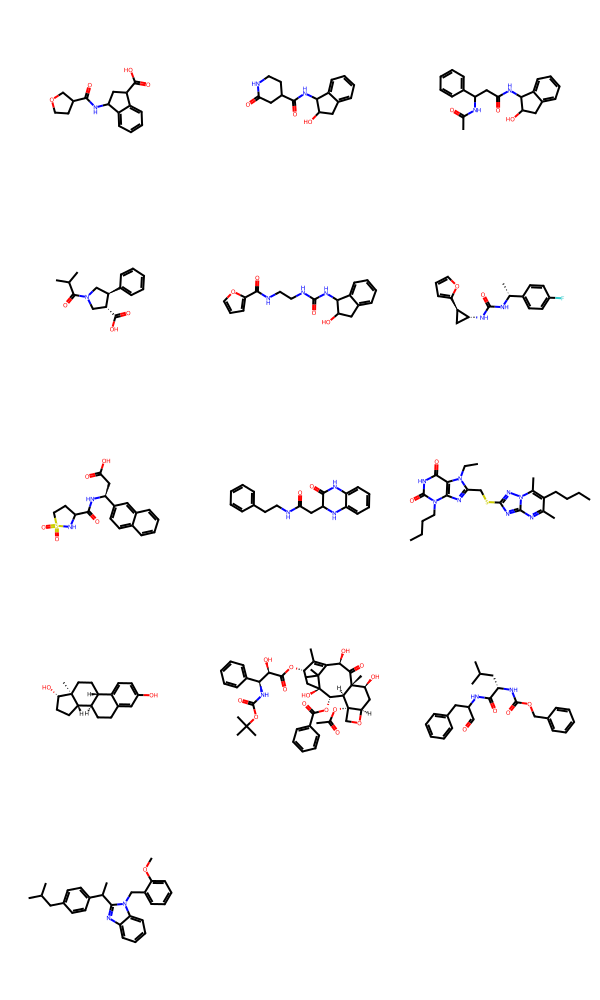

In [93]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.5 (best predicted molecule)

In [94]:
EnamineAntiviralsData_final_rankScore_best = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.5
]
EnamineAntiviralsData_final_rankScore_best

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
16348,7.29,SARS-CoV-2,0.427,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.18, Ebola:0.17",7.504,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic


In [95]:
EnamineAntiviralsData_final_rankScore_best.shape

(1, 8)

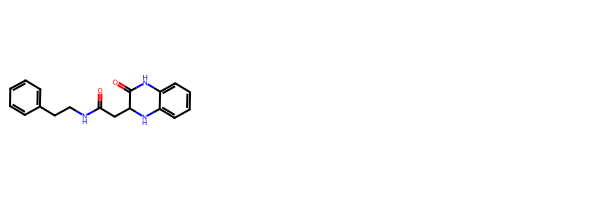

In [96]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore_best.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Extract molecular properties of the best predicted drug molecule

In [97]:
bestDrugMoleculeSMILES = EnamineAntiviralsData_final_rankScore_best["Smiles"]

smilesList = bestDrugMoleculeSMILES.tolist()
print(f"Number of top molecules: {len(smilesList)}")

Number of top molecules: 1


Convert each SMILES to RDKit molecule objects

In [100]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

mols = [Chem.MolFromSmiles(smi) for smi in smilesList if Chem.MolFromSmiles(smi) is not None]
print(f"Successfully parsed {len(mols)} valid molecules out of {len(smilesList)}")

# Remove or fix the problematic line

molProps = []
for i, mol in enumerate(mols):
    props = {
        "index": i,
        "SMILES": Chem.MolToSmiles(mol),
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "QED": Descriptors.qed(mol),
    }
    molProps.append(props)

molPropsDF = pd.DataFrame(molProps)
molPropsDF.head()

Successfully parsed 1 valid molecules out of 1


,index,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,HeavyAtoms,QED
0,0,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,309.369,2.1682,70.23,3,3,5,2,23,0.792547


Add mordred properties

In [101]:
from mordred import Calculator, descriptors

# Build a calculator for ALL 2D descriptors (ignore 3D)
calc = Calculator(descriptors, ignore_3D=True)

# This returns a pandas DataFrame aligned to the order of `mols`
mordredDF = calc.pandas(mols, quiet=True, nproc=4)

# Mordred can output non-numeric and NaN/inf
# Replace infs with NaN
mordredDF = mordredDF.replace([np.inf, -np.inf], np.nan)
# Drop columns that are entirely NaN
mordredDF = mordredDF.dropna(axis=1, how="all")
# Keep only numeric columns
numericCols = mordredDF.select_dtypes(include=[np.number]).columns
mordredNumDF = mordredDF[numericCols].copy()
# Optionally fill remaining NaNs with 0 
mordredNumDF = mordredNumDF.fillna(0.0)

print(f"Mordred: {mordredDF.shape[1]} total columns, {mordredNumDF.shape[1]} numeric columns kept.")
mordredNumDF.head()

Mordred: 1613 total columns, 1453 numeric columns kept.


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,17.815569,13.474433,0,0,30.024382,2.391574,4.783148,30.024382,1.305408,4.056909,...,9.873595,56.955817,309.147727,7.36066,1394,32,116.0,132.0,6.416667,5.138889


Combine all the molecular descriptors

In [102]:
combinedDF = pd.concat(
    [molPropsDF.reset_index(drop=True), mordredNumDF.reset_index(drop=True)],
    axis=1
)
combinedDF

,index,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,HeavyAtoms,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,0,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,309.369,2.1682,70.23,3,3,5,2,23,...,9.873595,56.955817,309.147727,7.36066,1394,32,116.0,132.0,6.416667,5.138889
